<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
Здравствуй Ксения!<br>
Это Николай. И нам повезло - мы делаем интереснейший проект!<br>
Далее, я постарюсь прокомментировать сделанные шаги.<br>
Вперёд!
        
Чтобы меньше "мусорить эфир" и чтобы максимально наглядно отделяться от основного кода, есть предложение условиться в некоторых обозначениях:<br /> <br />
<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>Всё хорошо.</p>
</div>

<div class="alert alert-warning" style="border-color: darkorange; border-radius: 5px">
    <p><u><b>⚠️ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>Обрати внимание, есть потенциал</p>
</div>
    
    
<div class="alert alert-danger" style="border-color: darkred; border-radius: 5px">
    <p><u><b>❌ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>Нужно ещё раз глянуть</p>
</div>
        
<font color='green'>Как и всегда в спринтах - ставлю своей целью максимально помочь. Поэтому, все мои комментарии - это только способ передать свой опыт для помощи в твоих достижениях. 

# Промышленность

Металлургический комбинат «Стальная птица» стремится оптимизировать производственные расходы и снизить потребление электроэнергии на этапе обработки стали. Одним из ключевых факторов энергозатрат является режим нагрева расплава в ковше. Для повышения эффективности производства комбинату необходимо прогнозировать конечную температуру сплава и использовать модель для имитации технологического процесса.
_____
<b>Цель проекта:</b>

Целью проекта является разработка модели машинного обучения, способной прогнозировать конечную температуру сплава на основе параметров технологического процесса (режима нагрева, состава добавок и вспомогательных операций), для последующего использования в системе имитационного моделирования и оптимизации энергопотребления на металлургическом комбинате «Стальная птица».
_____

<b>Задачи проекта</b>

- Изучить технологический процесс обработки стали в ковше и определить ключевые этапы, влияющие на изменение температуры сплава.
- Исследовать структуру базы данных SQLite и проанализировать таблицы, содержащие информацию о нагреве, добавках материалов, продувке газом и измерениях температуры.
- Провести исследовательский анализ данных, включая проверку пропусков, аномалий и распределений признаков.
- Выполнить агрегацию данных по партиям и сформировать информативные признаки, отражающие режим нагрева и особенности технологического цикла.
- Построить и обучить модели машинного обучения для задачи регрессии конечной температуры сплава.
- Сравнить несколько алгоритмов (базовая модель, ансамблевые методы, нейронная сеть) и выбрать лучшую модель по метрике качества.
- Оценить качество итоговой модели (МАЕ не более 6.8) и проанализировать влияние признаков на прогноз с помощью методов интерпретации (SHAP).
- Сформулировать рекомендации по применению модели для имитации технологического процесса и снижения энергопотребления.
_____

<b>Описание данных</b>

Данные хранятся в базе SQLite и представлены несколькими таблицами, отражающими различные этапы обработки стали:
- `steel.data_arc` — данные о нагреве электродами (мощность, длительность нагрева);
- `steel.data_bulk` — объёмы добавленных сыпучих материалов;
- `steel.data_bulk_time` — время подачи сыпучих материалов;
- `steel.data_gas` — данные о продувке сплава газом;
- `steel.data_temp` — измерения температуры сплава;
- `steel.data_wire` — объёмы добавленной проволоки;
- `steel.data_wire_time` — время подачи проволочных материалов.

Данные позволяют восстановить последовательность технологических операций для каждой партии стали и использовать их для построения модели прогнозирования конечной температуры.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>ок, это хороший тон - дать описание проблематики.</p>
</div>

In [17]:
!pip install shap transliterate -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import warnings
import random
import time
import sqlite3
import re
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transliterate import translit
from scipy.stats import randint, uniform
from pandas.api.types import is_integer_dtype
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import shap
import torch
from torch import nn

In [19]:
RANDOM_STATE = 10326

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>ок, подготовились)

Загрузим таблицы sql

In [20]:
conn = sqlite3.connect('data/ds-plus-final.db')
cursor = conn.cursor()

In [21]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('data_arc',), ('data_bulk',), ('data_bulk_time',), ('data_wire_time',), ('contract',), ('personal',), ('phone',), ('internet',), ('data_gas',), ('data_temp',), ('data_wire',)]


In [22]:
pd.read_sql_query('PRAGMA table_info(data_bulk_time);', conn)

,cid,name,type,notnull,dflt_value,pk
0,0,key,INTEGER,0,None,0
1,1,Bulk 1,TEXT,0,None,0
2,2,Bulk 2,TEXT,0,None,0
3,3,Bulk 3,TEXT,0,None,0
4,4,Bulk 4,TEXT,0,None,0
5,5,Bulk 5,TEXT,0,None,0
6,6,Bulk 6,TEXT,0,None,0
7,7,Bulk 7,TEXT,0,None,0
8,8,Bulk 8,TEXT,0,None,0
9,9,Bulk 9,TEXT,0,None,0


In [23]:
tables = [
    'data_arc', 'data_bulk', 'data_bulk_time', 'data_wire_time',
    'data_gas', 'data_temp', 'data_wire'
]

dataframes = {}

for table in tables:
    dataframes[table] = pd.read_sql_query(f'SELECT * FROM {table};', conn)
    print(table, dataframes[table].shape)

data_arc (14876, 5)
data_bulk (3129, 16)
data_bulk_time (3129, 16)
data_wire_time (3081, 10)
data_gas (3239, 2)
data_temp (18092, 3)
data_wire (3081, 10)


Все таблицы содержат данные и их количество соответствует заявленному.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>можно сказать, данные почти на базе)

## Исследовательский анализ таблиц БД

### data_arc

In [24]:
data_arc = pd.read_sql_query(f'SELECT * FROM data_arc;', conn)

In [25]:
def show_df_info(df, name='DataFrame'):
    print(f'\n=== {name} ===')

    print('\nИнформация о данных:')
    df.info() 

    print('\nПервые строки:')
    display(df.head())

    print('\nОписательная статистика:')
    display(df.describe(include='all'))

In [26]:
show_df_info(data_arc, 'Данные об электродах')


=== Данные об электродах ===

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB

Первые строки:


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691



Описательная статистика:


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
count,14876.000000,14876,14876,14876.000000,14876.000000
unique,NaN,14876,14876,NaN,NaN
top,NaN,2019-05-03 11:02:14,2019-05-03 11:06:02,NaN,NaN
freq,NaN,1,1,NaN,NaN
mean,1615.220422,NaN,NaN,0.662752,0.438986
std,934.571502,NaN,NaN,0.258885,5.873485
min,1.000000,NaN,NaN,0.223120,-715.479924
25%,806.000000,NaN,NaN,0.467115,0.337175
50%,1617.000000,NaN,NaN,0.599587,0.441639
75%,2429.000000,NaN,NaN,0.830070,0.608201


Таблица содержит 14876 строк без пропусков. Столбцы `Начало нагрева дугой` и `Конец нагрева дугой` необходимо перевести в datetime формат. В условии указано, что у нас не стоит задача временных рядов.
Визуально бросается в глаза наличие отрицательной реактивной мощности - явная аномалия, так как мощность не может быть отрицательной.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
первые выводы) ОК.

ДЛя удобства приведем названия колонок к змеиному регистру.

In [27]:
col = ['key', 'BeginTime', 'EndTime', 'ActivePower', 'ReactivePower']

data_arc.columns = [col for col in col]
data_arc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   key            14876 non-null  int64  
 1   BeginTime      14876 non-null  object 
 2   EndTime        14876 non-null  object 
 3   ActivePower    14876 non-null  float64
 4   ReactivePower  14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


In [28]:
data_arc[(data_arc['ReactivePower'] < 0)]

,key,BeginTime,EndTime,ActivePower,ReactivePower
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924


In [29]:
data_arc[(data_arc['key'] == 2116)]

,key,BeginTime,EndTime,ActivePower,ReactivePower
9778,2116,2019-07-28 02:07:12,2019-07-28 02:09:14,0.787549,0.693881
9779,2116,2019-07-28 02:13:10,2019-07-28 02:15:25,0.580263,0.411498
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924
9781,2116,2019-07-28 02:29:11,2019-07-28 02:30:18,0.563641,0.408513


Наличие отрицательной  мощности физически невозможно. В данной партии только одно аномальное значение, однако чтобы сохранить достоверность данных, я удаляю эту партию.

In [30]:
bad_keys_arc = data_arc.loc[data_arc['ReactivePower'] < 0, 'key'].unique()
data_arc = data_arc[~data_arc['key'].isin(bad_keys_arc)]
data_arc.shape

(14872, 5)

<div class="alert alert-warning" style="border-color: darkorange; border-radius: 5px">
    <p><u><b>⚠️ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
    <p>всё верно, есть такое. Единственное, вот что замечу: в подобных проектах лучше оперировать понятием "объект моделирования". В нашем случае это ковш (партия, кей) в целом. А значит и проводить манипуляции надо именно с объектом. Т.е., если удалять что-то из данных, то целой (объект) не часть (строку)
</div>

<div class="alert alert-info">
<b>Комментарий студента:</b> Исправлено.
</div>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-success" style="border-color: green; border-radius: 5px">
<b> КОММЕНТАРИЙ МЕНТОРА 2</b><br>👍

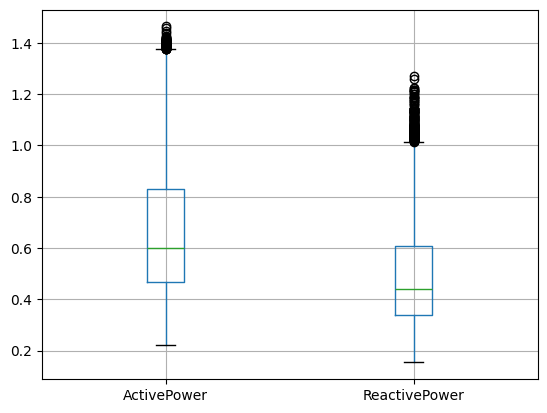

In [31]:
data_arc[['ActivePower', 'ReactivePower']].boxplot()
plt.show()

По медиане видно, что активная мощность, в среднем выше реактивной - это логично физически.                    
Много верхних выбросов, и отсутствие нижних - говорит о правосторонней ассиметрии распределения и редких пиковых режимов работы печи. Посмотрим насколько экстремальны выбросы.

In [32]:
data_arc['ActivePower'].quantile([0.95, 0.99])

0.95    1.179585
0.99    1.335990
Name: ActivePower, dtype: float64

Значения находятся достаточно близко друг к другу, что говорит скорее о пиковых режимах, чем аномалиях. Я делаю вывод, что это нормальная промышленная вариативность.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>ОК

Начало и конец нагрева переводу в datetime и сразу рассчитаю длительность нагрева.

In [33]:
data_arc['BeginTime'] = pd.to_datetime(data_arc['BeginTime'])
data_arc['EndTime'] = pd.to_datetime(data_arc['EndTime'])

data_arc['heating_time_sec'] = (
    data_arc['EndTime'] - data_arc['BeginTime']
).dt.total_seconds()

data_arc['heating_time_sec'].describe()

count    14872.000000
mean       171.688004
std         98.193604
min         11.000000
25%        107.000000
50%        147.000000
75%        214.000000
max        907.000000
Name: heating_time_sec, dtype: float64

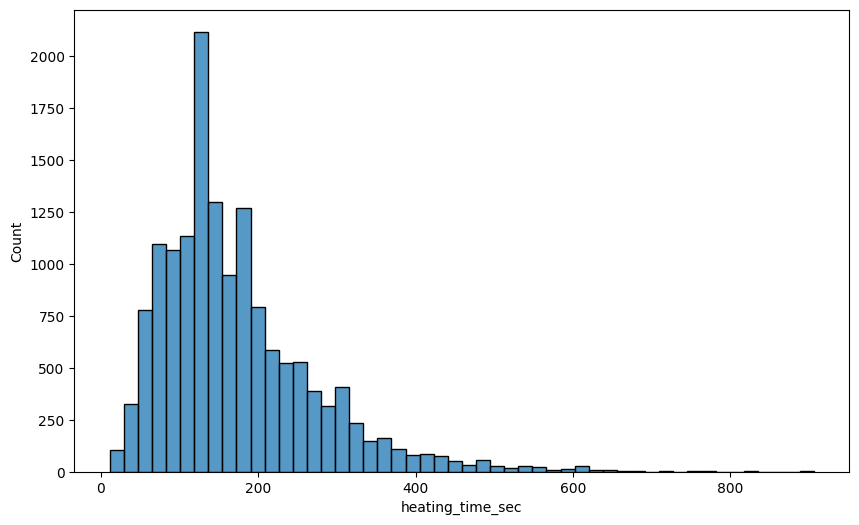

In [34]:
plt.figure(figsize=(10, 6))
sns.histplot(data_arc['heating_time_sec'], bins=50)
plt.show()

Стандартные нагревы идут 2-4 минуты, редко - значительно дольше до 30 мин.

In [35]:
data_arc['heating_time_sec'].quantile([0.95, 0.99])

0.95    360.45
0.99    508.29
Name: heating_time_sec, dtype: float64

Выглядит не критично.
Дополнительно посмотрю взаимосвязи между признаками.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>принято

<Figure size 1500x1000 with 0 Axes>

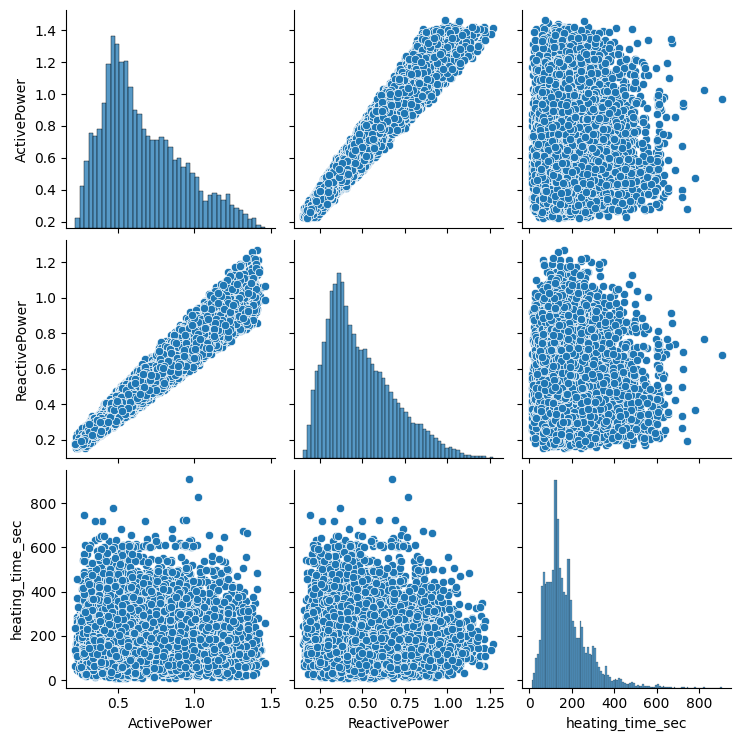

In [36]:
plt.figure(figsize=(15, 10))
sns.pairplot(data_arc[['ActivePower', 'ReactivePower', 'heating_time_sec']])
plt.show()

Основные выводы:
- `ActivePower` vs `ReactivePower` показывают сильную линейную зависимость. Возможно мультиколлинеарность, поэтому линейные модели в этой задаче точно не подойдут.
- `heating_time_sec` не имеет явной линейной зависимости с мощностями.
- имеет смысл добавить новые признаки, такие как полная мощность и коэффициент мощности.


<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>хорошо, идём дальше)

#### Дополнительные признаки

<b>Полная мощность</b> графически: активная мощность — это горизонтальная составляющая, реактивная — вертикальная, а полная — гипотенуза треугольника. Связь между ними выражается формулой:

$
S = \sqrt{P^2 + Q^2}
$

In [37]:
data_arc['full_power'] = np.sqrt(
    data_arc['ActivePower']**2 + data_arc['ReactivePower']**2
)
data_arc['full_power'].describe()

count    14872.000000
mean         0.823385
std          0.323494
min          0.275718
25%          0.578813
50%          0.746591
75%          1.030390
max          1.898158
Name: full_power, dtype: float64

Аномалий не видно. Признак стабильный.

<b>Соотношение активной к реактивной мощности</b> покажет насколько эффективно работает печь.
- активная мощность - реально нагревает металл
- реактивная - связана с индуктивностью оборудования, трансформаторами, дугой

Если соотношение низкое, то печь работает менее стабильно или менее эффективно.

In [38]:
data_arc['power_ratio'] = (
    data_arc['ActivePower'] / data_arc['ReactivePower']
)
data_arc['power_ratio'].describe()

count    14872.000000
mean         1.373513
std          0.130918
min          1.001742
25%          1.280145
50%          1.379778
75%          1.471221
max          1.857442
Name: power_ratio, dtype: float64

Данные говорят о стабильном электрическом режиме печи.

<b>Энергия нагрева</b>

$
Energy = P \times time
$

In [39]:
data_arc['energy'] = (
    data_arc['ActivePower'] * data_arc['heating_time_sec']
)
data_arc['energy'].describe()

count    14872.000000
mean       114.055512
std         83.013658
min          5.246505
25%         57.376903
50%         92.202561
75%        145.987744
max        898.200876
Name: energy, dtype: float64

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>новые факторы нам точно не помешают. ОК.

Очень большой разброс на макимуме, посмотрим выбросы ли это.

In [40]:
data_arc['energy'].quantile([0.95, 0.99])

0.95    274.508214
0.99    410.344851
Name: energy, dtype: float64

In [41]:
(data_arc['energy'] > 410).sum()

151

In [42]:
(data_arc['energy'] > 600).sum()

24

In [43]:
data_arc[data_arc['energy'] > 600][
    ['key', 'ActivePower', 'heating_time_sec', 'energy']
]

,key,ActivePower,heating_time_sec,energy
2027,437,1.317476,672.0,885.343872
2028,437,1.317139,508.0,669.106612
2661,580,0.923686,724.0,668.748664
3372,731,0.979567,633.0,620.065911
4654,1005,0.944134,725.0,684.497150
5019,1087,1.115246,540.0,602.232840
5024,1088,1.219890,497.0,606.285330
5272,1144,0.967024,627.0,606.324048
6014,1310,1.409275,483.0,680.679825
7799,1689,0.966775,907.0,876.864925


Похоже это партии с длинным нагревом. Если я удалю такие строки, то модель станет хуже предсказывать на высоких температурах.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>верно, не стоит удалять.

#### Агрегирование по партии

После расчета всех дополнительных признаков нужно сагрегировать данные по номеру партии.

In [44]:
arc_agg = data_arc.groupby('key').agg({
    'heating_time_sec': ['sum', 'mean', 'max'],
    'ActivePower': ['mean', 'max'],
    'ReactivePower': ['mean'],
    'full_power': ['mean'],
    'power_ratio': ['mean'],
    'energy': ['sum'],
    'key': 'count'
})

In [45]:
arc_agg.columns = [
    'total_heating_time',
    'mean_heating_time',
    'max_heating_time',
    'mean_active_power',
    'max_active_power',
    'mean_reactive_power',
    'mean_full_power',
    'mean_power_ratio',
    'total_energy',
    'heating_count'
]

arc_agg = arc_agg.reset_index()
arc_agg.head()

,key,total_heating_time,mean_heating_time,max_heating_time,mean_active_power,max_active_power,mean_reactive_power,mean_full_power,mean_power_ratio,total_energy,heating_count
0,1,1098.0,219.60,365.0,0.607346,0.867133,0.428564,0.743747,1.421570,628.616930,5
1,2,811.0,202.75,338.0,0.534852,0.786322,0.363339,0.647087,1.479201,395.281800,4
2,3,655.0,131.00,280.0,0.812728,1.222963,0.587491,1.003845,1.396069,581.774624,5
3,4,741.0,185.25,278.0,0.676622,0.887855,0.514248,0.850010,1.307446,543.710274,4
4,5,869.0,217.25,415.0,0.563238,0.892957,0.421998,0.704245,1.328894,412.180480,4


| Признак                 | Что означает                                             | Физический смысл / интерпретация                                                          |
| ----------------------- | -------------------------------------------------------- | ----------------------------------------------------------------------------------------- |
| **total_heating_time**  | Суммарное время нагрева партии                           | Общее время работы дуги. Чем больше — тем дольше партия находилась под нагревом.          |
| **mean_heating_time**   | Средняя длительность одного нагрева                      | Типичная продолжительность одного включения дуги.                                         |
| **max_heating_time**    | Максимальная длительность нагрева                        | Самый длинный цикл нагрева в партии. Может отражать нестандартный режим.                  |
| **mean_active_power**   | Средняя активная мощность                                | Средняя полезная мощность, которая реально нагревала металл.                              |
| **max_active_power**    | Максимальная активная мощность                           | Пиковая нагрузка печи. Показывает, были ли интенсивные этапы нагрева.                     |
| **mean_reactive_power** | Средняя реактивная мощность                              | Характеризует потери и электромагнитные процессы в системе.                               |
| **mean_full_power**     | Средняя полная мощность (S)                              | Общая нагрузка на электросеть: учитывает активную и реактивную составляющие.              |
| **mean_power_ratio**    | Среднее соотношение активной к реактивной мощности (P/Q) | Баланс полезной и реактивной энергии. Чем выше — тем эффективнее режим.                   |
| **total_energy**        | Суммарная энергия нагрева (P × t)                        | Общий объём энергии, потраченной на нагрев партии. Один из ключевых факторов температуры. |
| **heating_count**       | Количество запусков дуги                                 | Сколько раз включалась печь для данной партии. Характеризует технологический режим.       |


<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>я бы брал только суммарные факторы. Но ок, посмотрим далее.

### data_bulk

In [46]:
data_bulk = pd.read_sql_query(f'SELECT * FROM data_bulk;', conn)

In [47]:
show_df_info(data_bulk, 'Данные об объёме сыпучих материалов')


=== Данные об объёме сыпучих материалов ===

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     object 
 6   Bulk 6   576 non-null    object 
 7   Bulk 7   25 non-null     object 
 8   Bulk 8   1 non-null      object 
 9   Bulk 9   19 non-null     object 
 10  Bulk 10  176 non-null    object 
 11  Bulk 11  177 non-null    object 
 12  Bulk 12  2450 non-null   object 
 13  Bulk 13  18 non-null     object 
 14  Bulk 14  2806 non-null   object 
 15  Bulk 15  2248 non-null   object 
dtypes: float64(4), int64(1), object(11)
memory usage: 391.3+ KB

Первые строки:


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,None,None,None,None,None,None,None,206.0,None,150.0,154.0
1,2,NaN,NaN,NaN,73.0,None,None,None,None,None,None,None,206.0,None,149.0,154.0
2,3,NaN,NaN,NaN,34.0,None,None,None,None,None,None,None,205.0,None,152.0,153.0
3,4,NaN,NaN,NaN,81.0,None,None,None,None,None,None,None,207.0,None,153.0,154.0
4,5,NaN,NaN,NaN,78.0,None,None,None,None,None,None,None,203.0,None,151.0,152.0



Описательная статистика:


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000000,252.000000,22.000000,1298.000000,1014.000000,77,576,25,1,19,176,177,2450,18,2806,2248
unique,NaN,NaN,NaN,NaN,NaN,55,205,25,1,10,77,101,331,14,284,156
top,NaN,NaN,NaN,NaN,NaN,74.0,76.0,178.0,49.0,68.0,105.0,18.0,206.0,154.0,102.0,104.0
freq,NaN,NaN,NaN,NaN,NaN,5,15,1,1,4,8,7,224,3,99,223
mean,1624.383509,39.242063,253.045455,113.879045,104.394477,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,933.337642,18.277654,21.180578,75.483494,48.184126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,10.000000,228.000000,6.000000,12.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,816.000000,27.000000,242.000000,58.000000,72.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1622.000000,31.000000,251.500000,97.500000,102.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2431.000000,46.000000,257.750000,152.000000,133.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Всего 3129 строк и 15 материалов.                       
Пропуск = материал НЕ добавляли. Значит в данном случае NaN это 0.         
Все столбцы bulk необходимо перевести в числовой формат.        

In [48]:
data_bulk = data_bulk.fillna(0)

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>согласен.

In [49]:
bulk_cols = [col for col in data_bulk.columns if col != 'key']

for col in bulk_cols:
    data_bulk[col] = pd.to_numeric(data_bulk[col], errors='coerce')

In [50]:
def to_snake_case_translit(name: str) -> str:
    '''
    Функция принимает строку на русском или смешанном языке и 
    преобразует её в удобный формат snake_case с одновременной 
    транслитерацией в латиницу
    '''
    name = translit(name, 'ru', reversed=True)
    name = re.sub(r'(?<!^)(?=[A-Z])', '_', name)
    name = re.sub(r'[^A-Za-z0-9]+', '_', name)
    name = re.sub(r'_+', '_', name)
    name = name.strip('_')
    return name.lower()

data_bulk.columns = [to_snake_case_translit(col) for col in data_bulk.columns]
data_bulk.describe()

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
count,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000
mean,1624.383509,3.160435,1.779163,47.240332,33.830617,2.633749,21.892298,2.441675,0.015660,0.463407,4.684564,4.345478,203.948226,1.041866,152.706616,115.319271
std,933.337642,11.869164,21.217878,74.239954,56.034505,20.918138,55.492582,31.944063,0.875978,6.154398,20.157323,22.699580,151.419639,14.114252,81.091421,84.488698
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,816.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,105.000000,0.000000,104.000000,0.000000
50%,1622.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,0.000000,148.000000,106.000000
75%,2431.000000,0.000000,0.000000,80.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,263.000000,0.000000,202.000000,204.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.000000,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


- 25%, 50%, 75% почти у всех bulk = 0
- данные очень разреженные
- большинство материалов добавляются редко.

Основной материал - `bulk_12`, `bulk_14`, `bulk_15`         
Используются реже - `bulk_3` и `bulk_4`            
Используются крайне редко - `bulk_8`, `bulk_9`, `bulk_13`          

Явных аномалий нет.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
хорошо.

#### Дополнительные признаки 

<b>Общее количество добавок</b>

In [51]:
bulk_cols = data_bulk.columns.drop('key')   
data_bulk['total_bulk'] = data_bulk[bulk_cols].sum(axis=1)
data_bulk['total_bulk'].describe()

count    3129.000000
mean      595.503356
std       276.557794
min        19.000000
25%       429.000000
50%       591.000000
75%       772.000000
max      3235.000000
Name: total_bulk, dtype: float64

- В среднем в партию добавляют ~600 единиц материала
- Есть тяжёлые партии с большим объёмом добавок
- Минимум 19 → даже самые лёгкие партии всё равно что-то получают
- Нулевых партий нет → всегда что-то добавляют.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>)

<b>Количество типов добавленных материалов</b>

In [52]:
data_bulk['bulk_types_count'] = (data_bulk[bulk_cols] > 0).sum(axis=1)
data_bulk['bulk_types_count'].describe()

count    3129.000000
mean        3.566315
std         1.216165
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         7.000000
Name: bulk_types_count, dtype: float64

- Обычно используется 3–4 типа добавок
- Максимум 7 — технологически разумно
- Нет экстремальных значений

<b>Доля каждого материала</b>

In [53]:
for col in bulk_cols:
    data_bulk[col + '_share'] = data_bulk[col] / data_bulk['total_bulk']
data_bulk.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   key               3129 non-null   int64  
 1   bulk_1            3129 non-null   float64
 2   bulk_2            3129 non-null   float64
 3   bulk_3            3129 non-null   float64
 4   bulk_4            3129 non-null   float64
 5   bulk_5            3129 non-null   float64
 6   bulk_6            3129 non-null   float64
 7   bulk_7            3129 non-null   float64
 8   bulk_8            3129 non-null   float64
 9   bulk_9            3129 non-null   float64
 10  bulk_10           3129 non-null   float64
 11  bulk_11           3129 non-null   float64
 12  bulk_12           3129 non-null   float64
 13  bulk_13           3129 non-null   float64
 14  bulk_14           3129 non-null   float64
 15  bulk_15           3129 non-null   float64
 16  total_bulk        3129 non-null   float64


| Новый признак        | Формула               | Что означает                                     | Зачем нужен                                                           |
| -------------------- | --------------------- | ------------------------------------------------ | --------------------------------------------------------------------- |
| **total_bulk**       | Σ bulk_i              | Суммарный объём всех добавок в партии            | Характеризует общий масштаб рецептуры                                 |
| **bulk_types_count** | Количество bulk_i > 0 | Сколько разных типов материалов использовано     | Показывает сложность и вариативность состава                          |
| **bulk_i_share**     | bulk_i / total_bulk   | Доля конкретного материала в общей массе добавок | Позволяет анализировать структуру рецептуры независимо от её масштаба |


<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>ок

### data_bulk_time

In [54]:
data_bulk_time = pd.read_sql_query(f'SELECT * FROM data_bulk_time;', conn)

In [55]:
show_df_info(data_bulk_time, 'Данные о времени подачи сыпучих материалов')


=== Данные о времени подачи сыпучих материалов ===

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   Bulk 1   252 non-null    object
 2   Bulk 2   22 non-null     object
 3   Bulk 3   1298 non-null   object
 4   Bulk 4   1014 non-null   object
 5   Bulk 5   77 non-null     object
 6   Bulk 6   576 non-null    object
 7   Bulk 7   25 non-null     object
 8   Bulk 8   1 non-null      object
 9   Bulk 9   19 non-null     object
 10  Bulk 10  176 non-null    object
 11  Bulk 11  177 non-null    object
 12  Bulk 12  2450 non-null   object
 13  Bulk 13  18 non-null     object
 14  Bulk 14  2806 non-null   object
 15  Bulk 15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.3+ KB

Первые строки:


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,None,None,None,2019-05-03 11:28:48,None,None,None,None,None,None,None,2019-05-03 11:24:31,None,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,None,None,None,2019-05-03 11:36:50,None,None,None,None,None,None,None,2019-05-03 11:53:30,None,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,None,None,None,2019-05-03 12:32:39,None,None,None,None,None,None,None,2019-05-03 12:27:13,None,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,None,None,None,2019-05-03 12:43:22,None,None,None,None,None,None,None,2019-05-03 12:58:00,None,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,None,None,None,2019-05-03 13:30:47,None,None,None,None,None,None,None,2019-05-03 13:30:47,None,2019-05-03 13:34:12,2019-05-03 13:30:47



Описательная статистика:


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000000,252,22,1298,1014,77,576,25,1,19,176,177,2450,18,2806,2248
unique,NaN,252,22,1298,1014,77,576,25,1,19,176,177,2450,18,2806,2248
top,NaN,2019-05-03 17:42:46,2019-05-07 15:39:35,2019-05-03 20:40:25,2019-05-03 11:28:48,2019-05-07 15:19:17,2019-05-03 19:09:15,2019-05-07 18:11:01,2019-07-08 17:14:53,2019-05-14 11:57:58,2019-05-06 07:54:02,2019-05-05 23:43:24,2019-05-03 11:24:31,2019-05-05 02:10:21,2019-05-03 11:14:50,2019-05-03 11:10:43
freq,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
mean,1624.383509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,933.337642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,816.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1622.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2431.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Всего 3129 строк и 15 материалов.                       
Пропуск = материал НЕ добавляли. Значит в данном случае NaN это 0.         
Все столбцы bulk необходимо перевести в datetime формат.        

In [56]:
bulk_time_cols = [col for col in data_bulk_time.columns if col != 'key']

for col in bulk_time_cols:
    data_bulk_time[col] = pd.to_datetime(data_bulk_time[col])

data_bulk_time.columns = [
    to_snake_case_translit(col) if col == 'key'
    else to_snake_case_translit(col) + '_time'
    for col in data_bulk_time.columns
]
data_bulk_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   key           3129 non-null   int64         
 1   bulk_1_time   252 non-null    datetime64[ns]
 2   bulk_2_time   22 non-null     datetime64[ns]
 3   bulk_3_time   1298 non-null   datetime64[ns]
 4   bulk_4_time   1014 non-null   datetime64[ns]
 5   bulk_5_time   77 non-null     datetime64[ns]
 6   bulk_6_time   576 non-null    datetime64[ns]
 7   bulk_7_time   25 non-null     datetime64[ns]
 8   bulk_8_time   1 non-null      datetime64[ns]
 9   bulk_9_time   19 non-null     datetime64[ns]
 10  bulk_10_time  176 non-null    datetime64[ns]
 11  bulk_11_time  177 non-null    datetime64[ns]
 12  bulk_12_time  2450 non-null   datetime64[ns]
 13  bulk_13_time  18 non-null     datetime64[ns]
 14  bulk_14_time  2806 non-null   datetime64[ns]
 15  bulk_15_time  2248 non-null   datetime

In [57]:
data_bulk_time.describe()

,key,bulk_1_time,bulk_2_time,bulk_3_time,bulk_4_time,bulk_5_time,bulk_6_time,bulk_7_time,bulk_8_time,bulk_9_time,bulk_10_time,bulk_11_time,bulk_12_time,bulk_13_time,bulk_14_time,bulk_15_time
count,3129.000000,252,22,1298,1014,77,576,25,1,19,176,177,2450,18,2806,2248
mean,1624.383509,2019-06-29 23:24:44.769841152,2019-07-12 07:57:13.045454592,2019-07-08 13:50:14.630970624,2019-07-03 11:17:28.834319616,2019-07-13 17:18:29.090908928,2019-07-06 13:50:06.345486080,2019-07-27 18:09:05.079999744,2019-07-08 17:14:53,2019-06-23 08:08:47.578947328,2019-07-06 23:55:10.954545408,2019-07-15 07:01:00.615819264,2019-07-05 22:55:11.468571392,2019-07-01 18:32:46.944444416,2019-07-06 07:17:48.372772608,2019-07-06 13:24:51.912366336
min,1.000000,2019-05-03 17:42:46,2019-05-07 15:39:35,2019-05-03 20:40:25,2019-05-03 11:28:48,2019-05-07 15:19:17,2019-05-03 19:09:15,2019-05-07 18:11:01,2019-07-08 17:14:53,2019-05-14 11:57:58,2019-05-06 07:54:02,2019-05-05 23:43:24,2019-05-03 11:24:31,2019-05-05 02:10:21,2019-05-03 11:14:50,2019-05-03 11:10:43
25%,816.000000,2019-05-29 14:48:48.500000,2019-05-28 02:29:31.500000,2019-06-08 03:50:23.500000,2019-05-30 21:36:11.249999872,2019-06-19 23:32:44,2019-06-06 22:46:10.500000,2019-07-20 23:48:47,2019-07-08 17:14:53,2019-05-14 14:31:08,2019-06-02 05:12:00.500000,2019-06-14 20:24:48,2019-06-03 12:48:47.249999872,2019-05-29 10:43:31.249999872,2019-06-04 04:50:42,2019-06-04 11:28:18
50%,1622.000000,2019-06-25 11:09:13,2019-07-27 17:18:38.500000,2019-07-04 09:31:42,2019-06-28 03:44:42.500000,2019-07-25 17:59:41,2019-07-09 03:34:57.500000,2019-07-27 18:07:02,2019-07-08 17:14:53,2019-05-14 16:55:09,2019-07-06 07:05:20,2019-07-24 11:17:22,2019-07-03 01:32:00,2019-07-01 12:59:36.500000,2019-07-03 21:54:13.500000,2019-07-03 16:43:28.500000
75%,2431.000000,2019-07-31 05:58:18.249999872,2019-08-13 02:20:08,2019-08-11 01:00:36.750000128,2019-08-04 04:15:46.500000,2019-08-13 04:23:23,2019-08-07 18:55:01.249999872,2019-08-13 04:19:43,2019-07-08 17:14:53,2019-08-16 05:43:31,2019-08-04 02:23:35.750000128,2019-08-11 05:21:01,2019-08-08 14:55:05.249999872,2019-08-04 23:32:00.249999872,2019-08-09 04:22:40.500000,2019-08-09 09:18:31.750000128
max,3241.000000,2019-09-05 09:11:32,2019-08-13 11:47:39,2019-09-06 12:26:52,2019-09-05 03:35:21,2019-09-02 18:16:52,2019-09-06 16:24:28,2019-09-05 19:07:49,2019-07-08 17:14:53,2019-08-16 09:11:56,2019-09-04 10:03:22,2019-09-06 05:03:14,2019-09-06 15:01:44,2019-09-01 01:53:02,2019-09-06 17:26:33,2019-09-06 17:23:15
std,933.337642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Пропуски (NaT) в таблице интерпретируются как отсутствие добавления материала.            
Замена на 0 я производить не буду, во избежание искажения временной структуры.       

По диапазону дат данные выглядят адекватно.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>хорошо, да и время нам это можно в модели не учитывать.

#### Дополнительные признаки 

In [58]:
data_bulk_time.iloc[:, 1:].apply(lambda x: x.max() - x.min())

bulk_1_time    124 days 15:28:46
bulk_2_time     97 days 20:08:04
bulk_3_time    125 days 15:46:27
bulk_4_time    124 days 16:06:33
bulk_5_time    118 days 02:57:35
bulk_6_time    125 days 21:15:13
bulk_7_time    121 days 00:56:48
bulk_8_time      0 days 00:00:00
bulk_9_time     93 days 21:13:58
bulk_10_time   121 days 02:09:20
bulk_11_time   123 days 05:19:50
bulk_12_time   126 days 03:37:13
bulk_13_time   118 days 23:42:41
bulk_14_time   126 days 06:11:43
bulk_15_time   126 days 06:12:32
dtype: timedelta64[ns]

Производственный процесс длился около 4 месяцев.

Для проверки корректности временных данных в таблице рассчитаю интервал времени между первым и последним добавлением материала внутри одной партии.

Для каждой партии определяю:
- `first_addition` — самое раннее время подачи материала;
- `last_addition` — самое позднее время подачи;
- `addition_span` — разница между ними.

In [59]:
bulk_time_cols = data_bulk_time.columns.drop('key')

data_bulk_time['first_addition'] = data_bulk_time[bulk_time_cols].min(axis=1)
data_bulk_time['last_addition'] = data_bulk_time[bulk_time_cols].max(axis=1)

data_bulk_time['addition_span'] = (
    data_bulk_time['last_addition'] - data_bulk_time['first_addition']
)

data_bulk_time['addition_span'].describe()

count                         3129
mean     0 days 00:16:04.906679450
std      0 days 00:13:18.088024671
min                0 days 00:00:00
25%                0 days 00:08:05
50%                0 days 00:14:37
75%                0 days 00:21:51
max                0 days 03:48:03
Name: addition_span, dtype: object

Временной диапазон в целом выглядит технологически обоснованным:
подача добавок измеряется минутами и десятками минут, а не сутками или днями, что подтверждает корректность временных данных.

Максимальное значение (~3 часа 48 минут) существенно превышает среднее, однако не выглядит физически невозможным и может отражать сложный или нестандартный технологический режим.

In [60]:
(data_bulk_time['addition_span'] > pd.Timedelta(hours=2)).sum()

4

In [61]:
(data_bulk_time['addition_span'] > pd.Timedelta(hours=1)).sum()

27

In [62]:
data_bulk_time.loc[
    data_bulk_time['addition_span'] == data_bulk_time['addition_span'].max()
]

,key,bulk_1_time,bulk_2_time,bulk_3_time,bulk_4_time,bulk_5_time,bulk_6_time,bulk_7_time,bulk_8_time,bulk_9_time,bulk_10_time,bulk_11_time,bulk_12_time,bulk_13_time,bulk_14_time,bulk_15_time,first_addition,last_addition,addition_span
1895,1958,NaT,NaT,2019-07-21 14:44:03,NaT,NaT,2019-07-21 14:39:15,NaT,NaT,NaT,NaT,NaT,2019-07-21 14:31:46,NaT,2019-07-21 14:27:11,2019-07-21 10:56:00,2019-07-21 10:56:00,2019-07-21 14:44:03,0 days 03:48:03


Выяявлено 4 партии с длительностью подачи материалов более 2 часов и 27 партий более 1 часа (менее 1% выборки). 

Проверка случая самого долгого по времени подачи материала в плавку показала, что данные скорее всего отражают редкие, но возможные технологические режимы. Оснований для удаления пока не вижу.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>хорошо, согласен.

### data_gas

In [63]:
data_gas = pd.read_sql_query(f'SELECT * FROM data_gas;', conn)

In [64]:
show_df_info(data_gas, 'Данные о продувке сплава газом')


=== Данные о продувке сплава газом ===

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB

Первые строки:


,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692



Описательная статистика:


,key,Газ 1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


3239 строк без пропусков. Всего 2 столбца - партия - объём подаваемого газа.

Распределение расхода газа имеет выраженный правый хвост. Большинство партий потребляют от 7 до 14 условных единиц газа, однако встречаются редкие партии с повышенным расходом (до ~78)

In [65]:
col = ['key', 'gas']
data_gas.columns = [col for col in col]

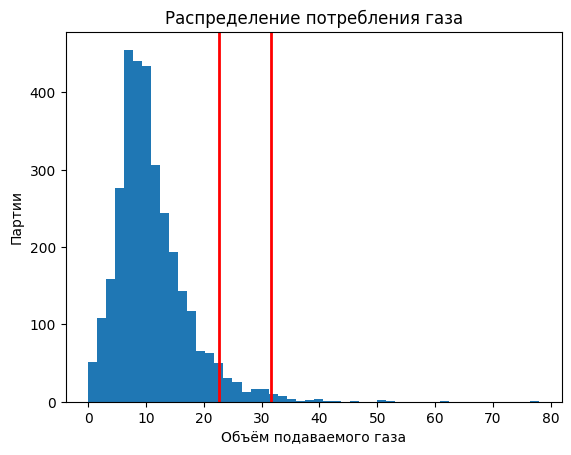

95th percentile: 22.626203215460002
99th percentile: 31.558630164365983


In [66]:
gas = data_gas['gas']

# Перцентили
p95 = gas.quantile(0.95)
p99 = gas.quantile(0.99)

plt.figure()
plt.hist(gas, bins=50)

# Красные линии перцентилей
plt.axvline(p95, color='red', linewidth=2)
plt.axvline(p99, color='red', linewidth=2)

plt.xlabel('Объём подаваемого газа')
plt.ylabel('Партии')
plt.title('Распределение потребления газа')

plt.show()

print('95th percentile:', p95)
print('99th percentile:', p99)

In [67]:
(data_gas['gas'] > 35).sum()

16

Выявлено 16 партий с расходом газа значительно выше 99-го перцентиля (до ~78 единиц). Анализ сопутствующих технологических параметров не выявил критических отклонений по длительности нагрева или энергии процесса. 
С учетом, что по условию не будут использоваться линейные модели, я не буду удалять эти выбросы, так как бустинги не чувствительны к ним.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>и тут согласен.

### data_temp

In [68]:
data_temp = pd.read_sql_query(f'SELECT * FROM data_temp;', conn)

In [69]:
show_df_info(data_temp, 'Данные об измерениях температуры')


=== Данные об измерениях температуры ===

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   key           18092 non-null  int64 
 1   Время замера  18092 non-null  object
 2   Температура   14665 non-null  object
dtypes: int64(1), object(2)
memory usage: 424.2+ KB

Первые строки:


,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0



Описательная статистика:


,key,Время замера,Температура
count,18092.000000,18092,14665
unique,NaN,18092,172
top,NaN,2019-05-03 11:02:04,1593.0
freq,NaN,1,445
mean,1616.460977,NaN,NaN
std,934.641385,NaN,NaN
min,1.000000,NaN,NaN
25%,807.750000,NaN,NaN
50%,1618.000000,NaN,NaN
75%,2429.000000,NaN,NaN


18092 строк, пропуски в температуре. Необходимо изменение типов данных.

In [70]:
col = ['key', 'time', 'temperature']
data_temp.columns = [col for col in col]

In [71]:
data_temp['time'] = pd.to_datetime(data_temp['time'])
data_temp['temperature'] = pd.to_numeric(data_temp['temperature'], errors='coerce')
data_temp.describe()

,key,time,temperature
count,18092.000000,18092,14665.000000
mean,1616.460977,2019-07-05 13:36:58.791620608,1590.722741
min,1.000000,2019-05-03 11:02:04,1191.000000
25%,807.750000,2019-06-04 00:35:01.249999872,1580.000000
50%,1618.000000,2019-07-03 02:11:48,1590.000000
75%,2429.000000,2019-08-07 23:10:05.249999872,1599.000000
max,3241.000000,2019-09-06 17:30:05,1705.000000
std,934.641385,NaN,20.394381


Температуры < 1500 — аномальны, и я вижу что такие данные присутствуют по минимуму значений температуры в 1191. Посмотрим сколько таких значений.

In [72]:
data_temp[(data_temp['temperature'] < 1500)]

,key,time,temperature
4883,867,2019-06-06 08:03:39,1191.0
6784,1214,2019-06-18 08:01:03,1208.0
9050,1619,2019-07-03 02:34:41,1218.0
11495,2052,2019-07-25 08:49:15,1227.0
14283,2561,2019-08-12 18:49:29,1204.0


Всего 5 - удаляем аномалии.

In [73]:
data_temp = data_temp[(data_temp['temperature'] >= 1500)]
data_temp.describe()

,key,time,temperature
count,14660.000000,14660,14660.000000
mean,1325.369236,2019-06-23 23:52:37.136425728,1590.852729
min,1.000000,2019-05-03 11:02:04,1515.000000
25%,654.000000,2019-05-28 23:48:07.500000,1580.000000
50%,1314.000000,2019-06-21 22:52:35.500000,1590.000000
75%,1962.250000,2019-07-21 22:38:38,1599.000000
max,3241.000000,2019-09-06 16:48:55,1705.000000
std,787.407873,NaN,19.143141


<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>с этими выбросами - поддерживаю удаление.Как и писал с реактивной - правильнее удалять именно объект моделирования в целом.

#### Агрегирование по партии

Так же в условии сказано, что мы можем использовать только те партии, у которых как минимум два наблюдения.

In [74]:
counts = data_temp.groupby('key')['temperature'].count()
counts.describe()

count    3215.000000
mean        4.559876
std         2.405800
min         1.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        17.000000
Name: temperature, dtype: float64

In [75]:
valid_keys = counts[counts >= 2].index
data_temp = data_temp[data_temp['key'].isin(valid_keys)]
data_temp.shape

(13920, 3)

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>супер!!!! Это важнейший момент проекта - оставлять только нужные партии.

Теперь отсортируем во времени, так как мы можем использовать только начальную температуру как входной признак. Целевой признак — последняя температура партии. Все промежуточные температуры будут давать утечку данных.

In [76]:
data_temp = data_temp.sort_values(['key', 'time'])

In [77]:
temp_agg = data_temp.groupby('key').agg(
    first_temp=('temperature', 'first'),
    last_temp=('temperature', 'last')
).reset_index()

temp_agg.describe()

,key,first_temp,last_temp
count,2475.000000,2475.000000,2475.000000
mean,1250.787071,1589.029899,1595.336162
std,719.787271,24.998058,16.023153
min,1.000000,1519.000000,1541.000000
25%,629.500000,1572.000000,1587.000000
50%,1252.000000,1588.000000,1593.000000
75%,1872.500000,1605.000000,1599.000000
max,2499.000000,1679.000000,1700.000000


Все температуры удовлетворяют условию и физическим возможностям (не больше 2000).

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>понятно.

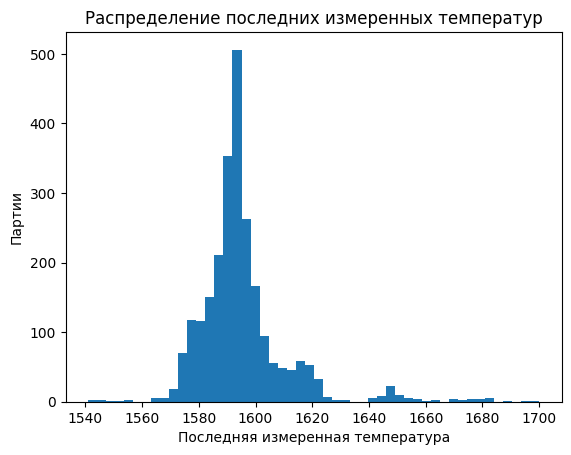

count    2475.000000
mean     1595.336162
std        16.023153
min      1541.000000
25%      1587.000000
50%      1593.000000
75%      1599.000000
max      1700.000000
Name: last_temp, dtype: float64

In [78]:
plt.hist(temp_agg['last_temp'], bins=50)
plt.xlabel('Последняя измеренная температура')
plt.ylabel('Партии')    
plt.title('Распределение последних измеренных температур')
plt.show()
temp_agg['last_temp'].describe()

Температура плавки стали обычно 1550-1650 градусов, иногда выше при доводке. Получившиеся данные полность вписываются в физику процесса.

### data_wire

In [79]:
data_wire = pd.read_sql_query(f'SELECT * FROM data_wire;', conn)

In [80]:
show_df_info(data_wire, 'Данные об объёме проволочных материалов')


=== Данные об объёме проволочных материалов ===

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   object 
 3   Wire 3  63 non-null     object 
 4   Wire 4  14 non-null     object 
 5   Wire 5  1 non-null      object 
 6   Wire 6  73 non-null     object 
 7   Wire 7  11 non-null     object 
 8   Wire 8  19 non-null     object 
 9   Wire 9  29 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 240.8+ KB

Первые строки:


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,None,None,None,None,None,None,None,None
1,2,96.052315,None,None,None,None,None,None,None,None
2,3,91.160157,None,None,None,None,None,None,None,None
3,4,89.063515,None,None,None,None,None,None,None,None
4,5,89.238236,9.11456,None,None,None,None,None,None,None



Описательная статистика:


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000000,3055.000000,1079,63,14,1,73,11,19,29
unique,NaN,NaN,713,56,14,1,69,10,13,25
top,NaN,NaN,30.09968,93.165077,24.148801,15.132,18.086641,12.354473,46.187439000000005,30.066399
freq,NaN,NaN,20,3,1,1,2,2,3,3
mean,1623.426485,100.895853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,932.996726,42.012518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,1.918800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,823.000000,72.115684,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1619.000000,100.158234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2434.000000,126.060483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


3081 строка, пропуски означают фактически 0 - материал в партию не добавлялся. Всего 9 проволочных материалов.
Все столбцы wire необходимо перевести в числовой формат.   

In [81]:
data_wire = data_wire.fillna(0)

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>и тут верно

In [82]:
wire_cols = [col for col in data_wire.columns if col != 'key']

for col in wire_cols:
    data_wire[col] = pd.to_numeric(data_wire[col], errors='coerce')

In [83]:
data_wire.columns = [to_snake_case_translit(col) for col in data_wire.columns]
data_wire.describe()

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
count,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000
mean,1623.426485,100.044411,17.712733,3.874524,0.261019,0.004911,1.137695,0.035842,0.330697,0.321492
std,932.996726,42.841120,33.517734,30.310417,4.293865,0.272615,8.958111,0.774190,4.392677,3.806904
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,823.000000,70.281120,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1619.000000,100.114563,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2434.000000,125.798405,23.162880,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132000,180.454575,32.847674,102.762401,90.053604


- 25%, 50%, 75% почти у всех wire = 0
- данные очень разреженные
- большинство материалов добавляются редко.

Основной материал - `wire_1`, `wire_2`   
Используются реже - `wire_3` и `wire_6`            
Используются крайне редко - `wire_5`, `wire_7`          

Явных аномалий нет.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>хорошо

#### Дополнительные признаки 

<b>Общее количество добавок</b>

In [84]:
wire_cols = data_wire.columns.drop('key')   
data_wire['total_wire'] = data_wire[wire_cols].sum(axis=1)
data_wire['total_wire'].describe()

count    3081.000000
mean      123.723326
std        66.082966
min         1.918800
25%        86.112000
50%       114.179523
75%       150.181198
max       663.851766
Name: total_wire, dtype: float64

- В среднем в партию добавляют 114 единиц проволочного материала
- Есть тяжёлые партии с большим объёмом добавок
- Минимум 1.9 → даже самые лёгкие партии всё равно что-то получают
- Нулевых партий нет → всегда что-то добавляют.

<b>Количество типов добавленных материалов</b>

In [85]:
data_wire['wire_types_count'] = (data_wire[wire_cols] > 0).sum(axis=1)
data_wire['wire_types_count'].describe()

count    3081.000000
mean        1.409932
std         0.578078
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: wire_types_count, dtype: float64

- Обычно используется 1тип добавок
- Максимум 5 — технологически разумно
- Нет экстремальных значений

<b>Доля каждого материала</b>

In [86]:
for col in wire_cols:
    data_wire[col + '_share'] = data_wire[col] / data_wire['total_wire']
data_wire.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   key               3081 non-null   int64  
 1   wire_1            3081 non-null   float64
 2   wire_2            3081 non-null   float64
 3   wire_3            3081 non-null   float64
 4   wire_4            3081 non-null   float64
 5   wire_5            3081 non-null   float64
 6   wire_6            3081 non-null   float64
 7   wire_7            3081 non-null   float64
 8   wire_8            3081 non-null   float64
 9   wire_9            3081 non-null   float64
 10  total_wire        3081 non-null   float64
 11  wire_types_count  3081 non-null   int64  
 12  wire_1_share      3081 non-null   float64
 13  wire_2_share      3081 non-null   float64
 14  wire_3_share      3081 non-null   float64
 15  wire_4_share      3081 non-null   float64
 16  wire_5_share      3081 non-null   float64


| Новый признак        | Формула               | Что означает                                     | Зачем нужен                                                           |
| -------------------- | --------------------- | ------------------------------------------------ | --------------------------------------------------------------------- |
| **total_wire**       | Σ wire_i              | Суммарный объём всех добавок в партии            | Характеризует общий масштаб рецептуры                                 |
| **wire_types_count** | Количество wire_i > 0 | Сколько разных типов проволочных материалов использовано     | Показывает сложность и вариативность состава                          |
| **wire_i_share**     | wire_i / total_wire  | Доля конкретного материала в общей массе добавок | Позволяет анализировать структуру рецептуры независимо от её масштаба |


### data_wire_time

In [87]:
data_wire_time = pd.read_sql_query(f'SELECT * FROM data_wire_time;', conn)

In [88]:
show_df_info(data_wire_time, 'Данные о времени подачи проволочных материалов')


=== Данные о времени подачи проволочных материалов ===

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   Wire 1  3055 non-null   object
 2   Wire 2  1079 non-null   object
 3   Wire 3  63 non-null     object
 4   Wire 4  14 non-null     object
 5   Wire 5  1 non-null      object
 6   Wire 6  73 non-null     object
 7   Wire 7  11 non-null     object
 8   Wire 8  19 non-null     object
 9   Wire 9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB

Первые строки:


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,None,None,None,None,None,None,None,None
1,2,2019-05-03 11:36:50,None,None,None,None,None,None,None,None
2,3,2019-05-03 12:11:46,None,None,None,None,None,None,None,None
3,4,2019-05-03 12:43:22,None,None,None,None,None,None,None,None
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,None,None,None,None,None,None,None



Описательная статистика:


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000000,3055,1079,63,14,1,73,11,19,29
unique,NaN,3055,1079,63,14,1,73,11,19,29
top,NaN,2019-05-03 11:06:19,2019-05-03 13:15:34,2019-05-04 04:34:27,2019-05-07 15:19:17,2019-08-13 06:14:30,2019-05-07 14:46:05,2019-07-27 05:49:05,2019-05-14 11:29:24,2019-05-04 17:21:27
freq,NaN,1,1,1,1,1,1,1,1,1
mean,1623.426485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,932.996726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,823.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1619.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2434.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Всего 3081 строк и 9 проволочных материалов.                       
Пропуск = материал НЕ добавляли. 
Все столбцы bulk необходимо перевести в datetime формат.        

In [89]:
wire_time_cols = [col for col in data_wire_time.columns if col != 'key']

for col in wire_time_cols:
    data_wire_time[col] = pd.to_datetime(data_wire_time[col])

data_wire_time.columns = [
    to_snake_case_translit(col) if col == 'key'
    else to_snake_case_translit(col) + '_time'
    for col in data_wire_time.columns
]
data_wire_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   key          3081 non-null   int64         
 1   wire_1_time  3055 non-null   datetime64[ns]
 2   wire_2_time  1079 non-null   datetime64[ns]
 3   wire_3_time  63 non-null     datetime64[ns]
 4   wire_4_time  14 non-null     datetime64[ns]
 5   wire_5_time  1 non-null      datetime64[ns]
 6   wire_6_time  73 non-null     datetime64[ns]
 7   wire_7_time  11 non-null     datetime64[ns]
 8   wire_8_time  19 non-null     datetime64[ns]
 9   wire_9_time  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9), int64(1)
memory usage: 240.8 KB


In [90]:
data_wire_time.describe()

,key,wire_1_time,wire_2_time,wire_3_time,wire_4_time,wire_5_time,wire_6_time,wire_7_time,wire_8_time,wire_9_time
count,3081.000000,3055,1079,63,14,1,73,11,19,29
mean,1623.426485,2019-07-05 23:22:34.279541760,2019-07-07 01:07:08.735866624,2019-07-10 15:09:58.650793472,2019-07-11 13:44:37,2019-08-13 06:14:30,2019-07-07 11:51:15.095890432,2019-08-07 01:16:08.090909184,2019-06-23 07:47:49.052631552,2019-07-01 11:56:04.793103616
min,1.000000,2019-05-03 11:06:19,2019-05-03 13:15:34,2019-05-04 04:34:27,2019-05-07 15:19:17,2019-08-13 06:14:30,2019-05-07 14:46:05,2019-07-27 05:49:05,2019-05-14 11:29:24,2019-05-04 17:21:27
25%,823.000000,2019-06-04 19:30:11.500000,2019-06-05 14:50:26.500000,2019-06-11 14:17:38.500000,2019-07-20 17:58:53.750000128,2019-08-13 06:14:30,2019-05-08 21:47:30,2019-07-27 16:27:27,2019-05-14 14:20:07.500000,2019-06-09 19:36:17
50%,1619.000000,2019-07-03 06:36:23,2019-07-04 23:13:39,2019-07-21 10:04:47,2019-07-27 05:45:26.500000,2019-08-13 06:14:30,2019-07-28 05:00:32,2019-08-12 21:48:11,2019-05-14 16:55:09,2019-06-11 10:10:21
75%,2434.000000,2019-08-08 08:56:06.500000,2019-08-08 23:15:17,2019-08-12 22:54:46,2019-07-27 16:20:04.750000128,2019-08-13 06:14:30,2019-08-13 13:33:02,2019-08-13 02:02:55.500000,2019-08-16 05:06:53.500000,2019-08-09 06:49:04
max,3241.000000,2019-09-06 17:10:06,2019-09-06 07:35:40,2019-09-02 07:14:44,2019-08-13 03:16:45,2019-08-13 06:14:30,2019-08-18 19:10:56,2019-08-13 10:25:22,2019-08-16 08:56:23,2019-09-03 12:55:23
std,932.996726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Пропуски (NaT) в таблице интерпретируются как отсутствие добавления материала.            
Замена на 0 я производить не буду, во избежание искажения временной структуры.       

По диапазону дат данные выглядят адекватно.

#### Дополнительные признаки 

In [91]:
data_wire_time.iloc[:, 1:].apply(lambda x: x.max() - x.min())

wire_1_time   126 days 06:03:47
wire_2_time   125 days 18:20:06
wire_3_time   121 days 02:40:17
wire_4_time    97 days 11:57:28
wire_5_time     0 days 00:00:00
wire_6_time   103 days 04:24:51
wire_7_time    17 days 04:36:17
wire_8_time    93 days 21:26:59
wire_9_time   121 days 19:33:56
dtype: timedelta64[ns]

Производственный процесс длился около 4 месяцев. Wire_5 добавляли всего 1 раз, поэтому его процесс вышел равным 0.

Для проверки корректности временных данных в таблице рассчитаю интервал времени между первым и последним добавлением материала внутри одной партии.

Для каждой партии определяю:
- `first_addition_wire` — самое раннее время подачи материала;
- `last_addition_wire` — самое позднее время подачи;
- `addition_span_wire` — разница между ними.

In [92]:
wire_time_cols = data_wire_time.columns.drop('key')

data_wire_time['first_addition_wire'] = data_wire_time[wire_time_cols].min(axis=1)
data_wire_time['last_addition_wire'] = data_wire_time[wire_time_cols].max(axis=1)

data_wire_time['addition_span_wire'] = (
    data_wire_time['last_addition_wire'] - data_wire_time['first_addition_wire']
)

data_wire_time['addition_span_wire'].describe()

count                         3081
mean     0 days 00:03:34.519311911
std      0 days 00:06:36.131967180
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:00:00
75%                0 days 00:06:41
max                0 days 01:38:57
Name: addition_span_wire, dtype: object

У более чем 50% партий была только одна подача проволоки, или добавления происходили в один момент.                
В большинстве партий добавление материала происходит в течение нескольких минут. Максимальное значение составляет около 1 часа 39 минут, что не превышает разумные технологические пределы. Аномалий в виде измерения времени в сутках или днях не выявлено.

## Объединение таблиц

Используем inner join, потому что во всех партиях должны быть:
- нагрев
- газ
- bulk
 - wire
- температура

In [93]:
data_agg = (
    temp_agg
    .merge(arc_agg, on='key', how='inner')
    .merge(data_bulk, on='key', how='inner')
    .merge(data_bulk_time, on='key', how='inner')
    .merge(data_wire, on='key', how='inner')
    .merge(data_wire_time, on='key', how='inner')
    .merge(data_gas, on='key', how='inner')
)
data_agg

,key,first_temp,last_temp,total_heating_time,mean_heating_time,max_heating_time,mean_active_power,max_active_power,mean_reactive_power,mean_full_power,...,wire_4_time,wire_5_time,wire_6_time,wire_7_time,wire_8_time,wire_9_time,first_addition_wire,last_addition_wire,addition_span_wire,gas
0,1,1571.0,1613.0,1098.0,219.600000,365.0,0.607346,0.867133,0.428564,0.743747,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:06:19,2019-05-03 11:06:19,0 days 00:00:00,29.749986
1,2,1581.0,1602.0,811.0,202.750000,338.0,0.534852,0.786322,0.363339,0.647087,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:36:50,2019-05-03 11:36:50,0 days 00:00:00,12.555561
2,3,1596.0,1599.0,655.0,131.000000,280.0,0.812728,1.222963,0.587491,1.003845,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:11:46,2019-05-03 12:11:46,0 days 00:00:00,28.554793
3,4,1601.0,1625.0,741.0,185.250000,278.0,0.676622,0.887855,0.514248,0.850010,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:43:22,2019-05-03 12:43:22,0 days 00:00:00,18.841219
4,5,1576.0,1602.0,869.0,217.250000,415.0,0.563238,0.892957,0.421998,0.704245,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:15:34,2019-05-03 13:20:44,0 days 00:05:10,5.413692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2323,2495,1570.0,1591.0,723.0,180.750000,234.0,0.792033,1.055713,0.552734,0.967180,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-08-10 11:31:40,2019-08-10 11:31:40,0 days 00:00:00,7.125735
2324,2496,1554.0,1591.0,940.0,156.666667,228.0,0.695820,1.309449,0.478672,0.845053,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-08-10 11:59:10,2019-08-10 11:59:10,0 days 00:00:00,9.412616
2325,2497,1571.0,1589.0,569.0,189.666667,207.0,1.201746,1.270521,0.817364,1.453639,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-08-10 12:40:30,2019-08-10 12:46:10,0 days 00:05:40,6.271699
2326,2498,1591.0,1594.0,750.0,150.000000,256.0,0.640462,0.999939,0.447964,0.781983,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-08-10 13:02:54,2019-08-10 13:02:54,0 days 00:00:00,14.953657


<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>отлично с иннером!

In [94]:
data_agg.shape

(2328, 96)

In [95]:
process_cols = [
    'first_temp',
    'last_temp',
    'total_energy',
    'total_heating_time',
    'mean_active_power',
    'mean_reactive_power',
    'mean_full_power',
    'mean_power_ratio',
    'heating_count',
    'gas',
    'total_bulk',
    'bulk_types_count',
    'total_wire',
    'wire_types_count',
]
data_agg[process_cols].isna().sum()

first_temp             0
last_temp              0
total_energy           0
total_heating_time     0
mean_active_power      0
mean_reactive_power    0
mean_full_power        0
mean_power_ratio       0
heating_count          0
gas                    0
total_bulk             0
bulk_types_count       0
total_wire             0
wire_types_count       0
dtype: int64

Условие выполнено. В процессных данных нет пропусков.

### Исследовательский анализ

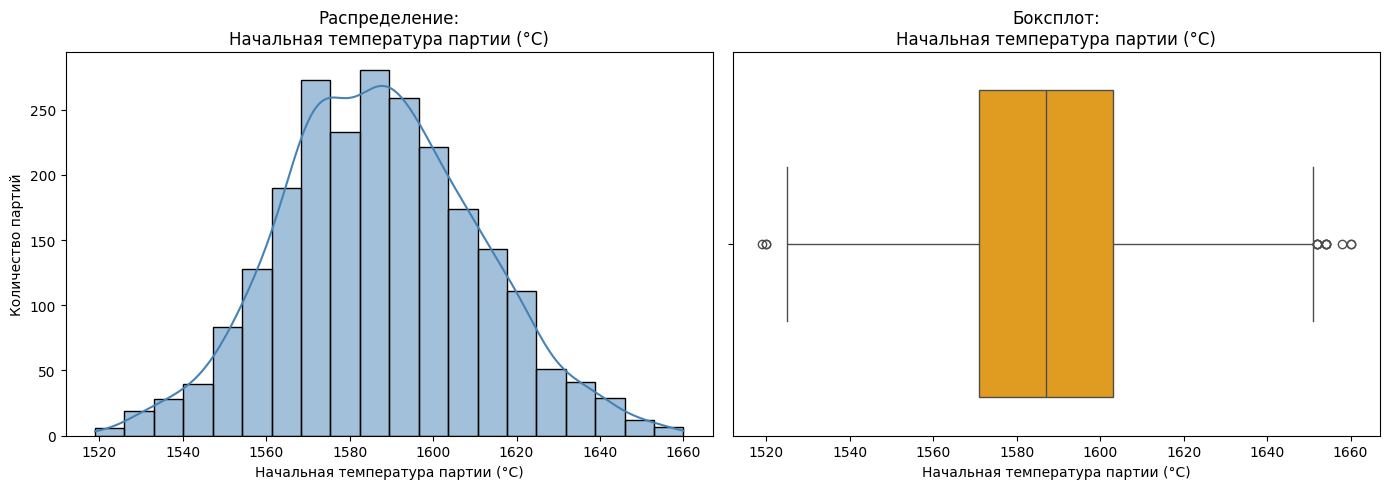

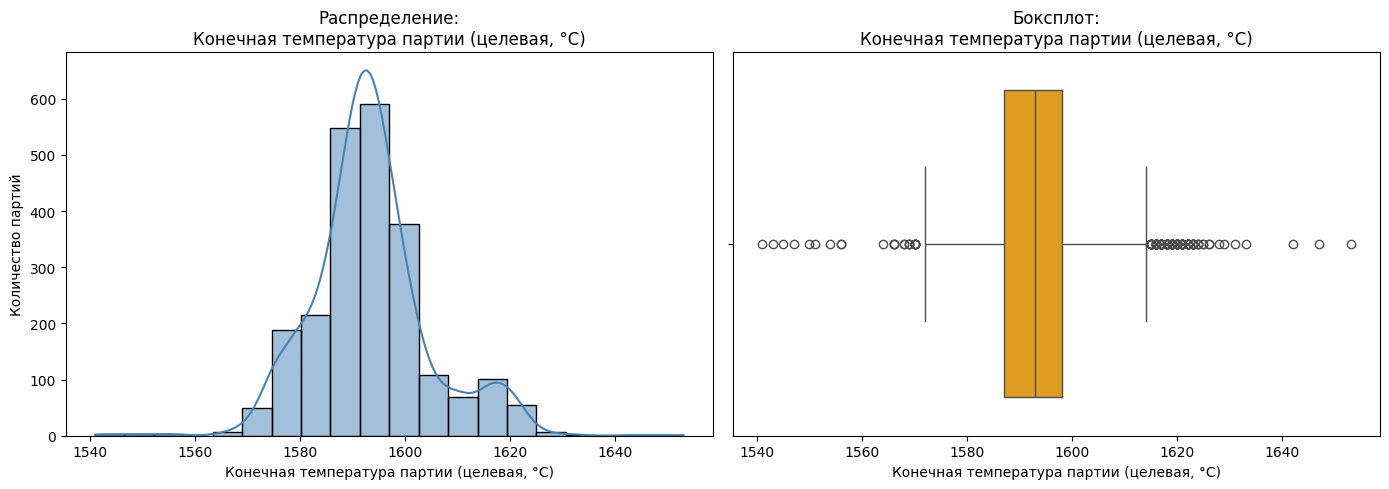

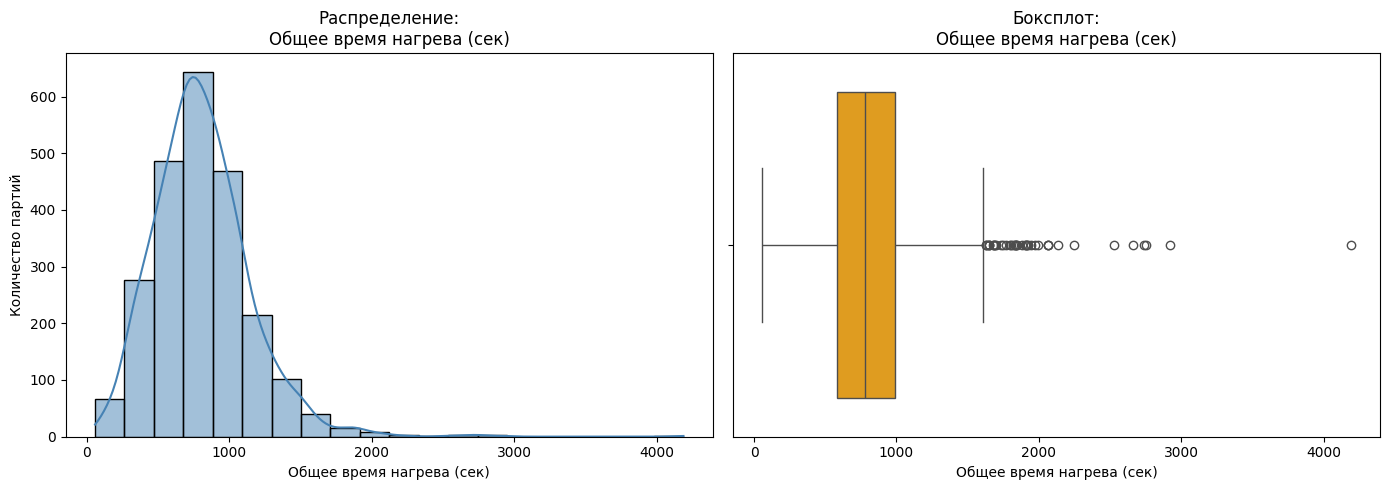

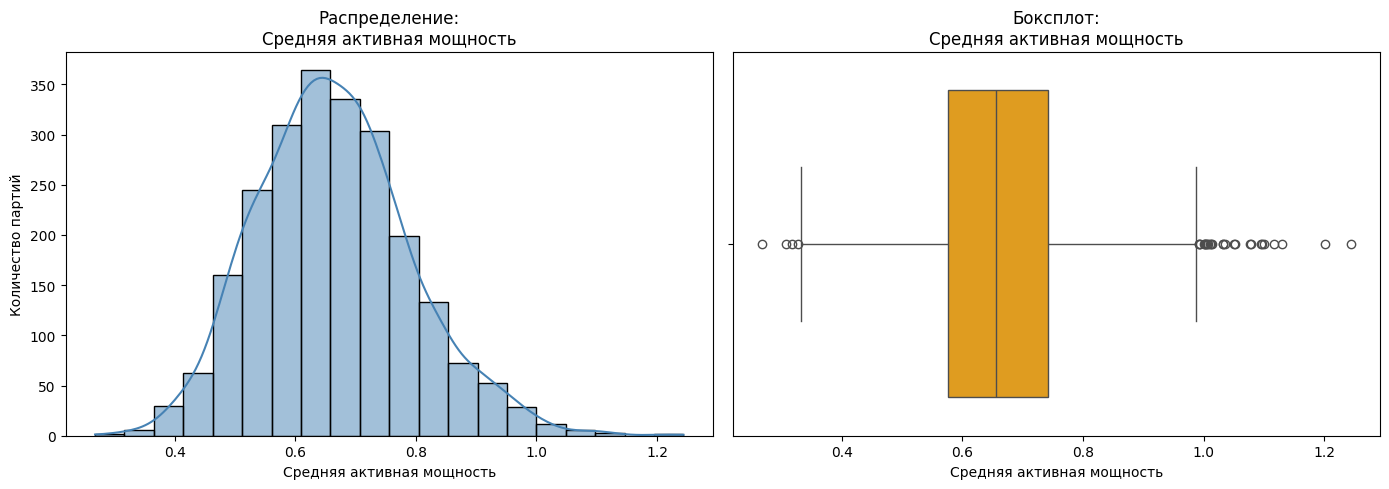

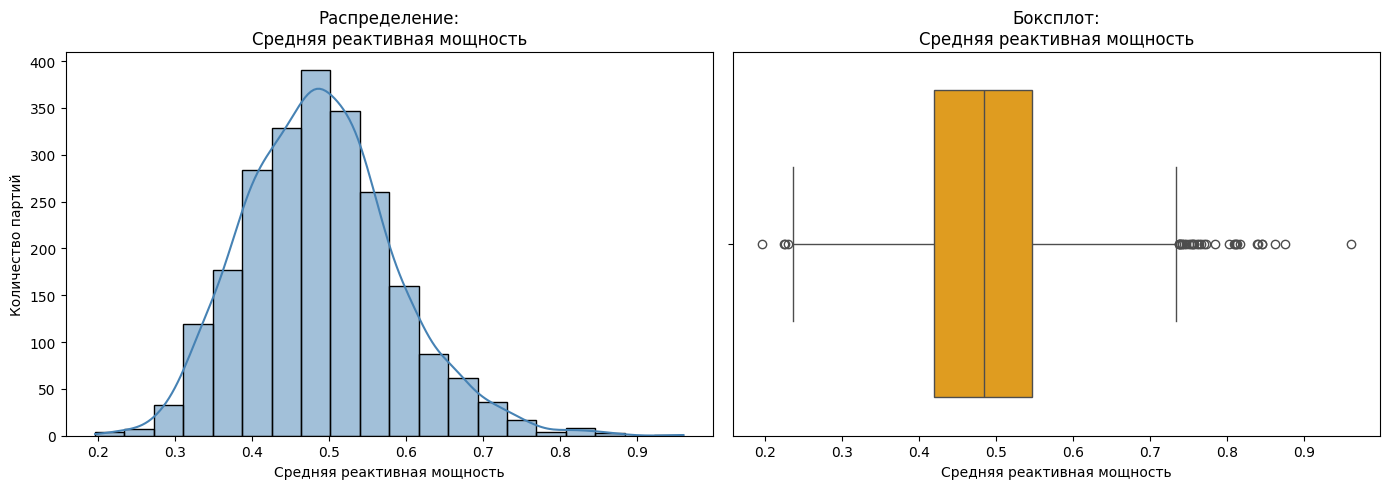

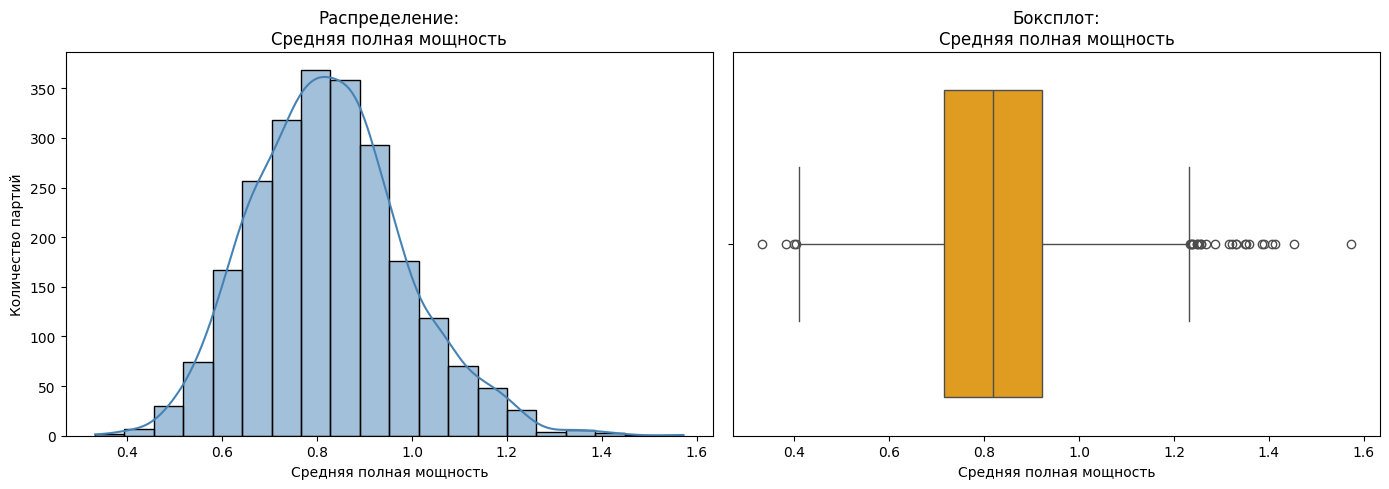

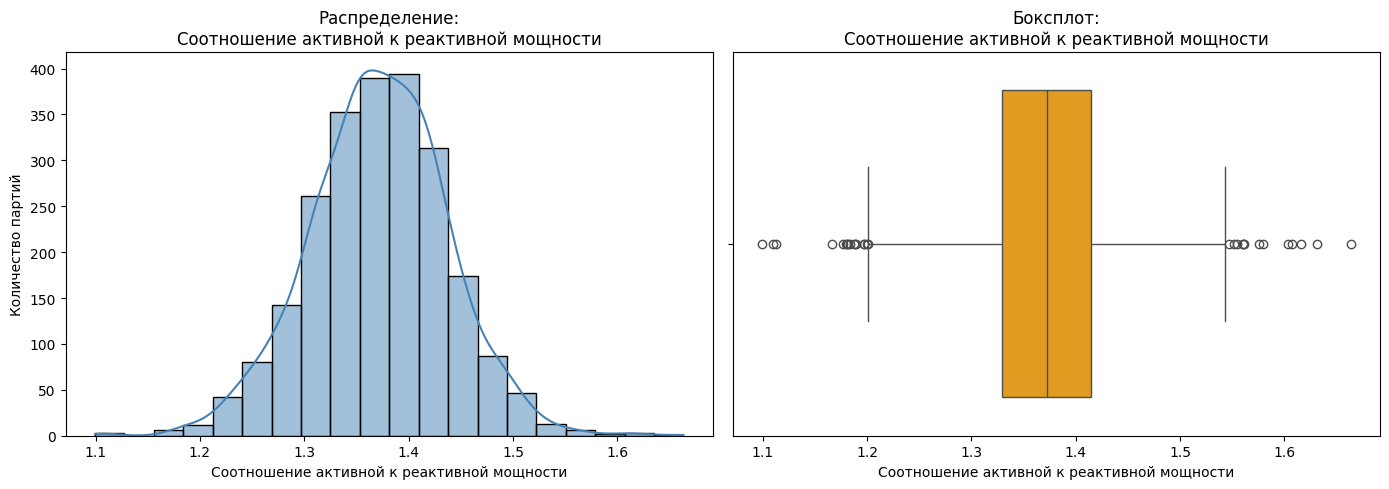

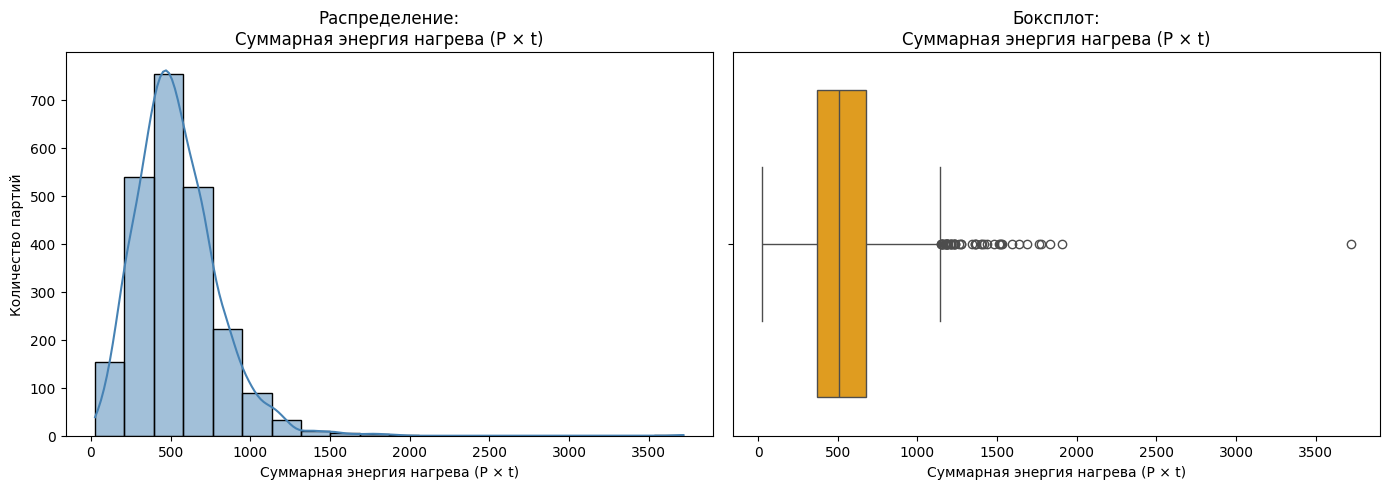

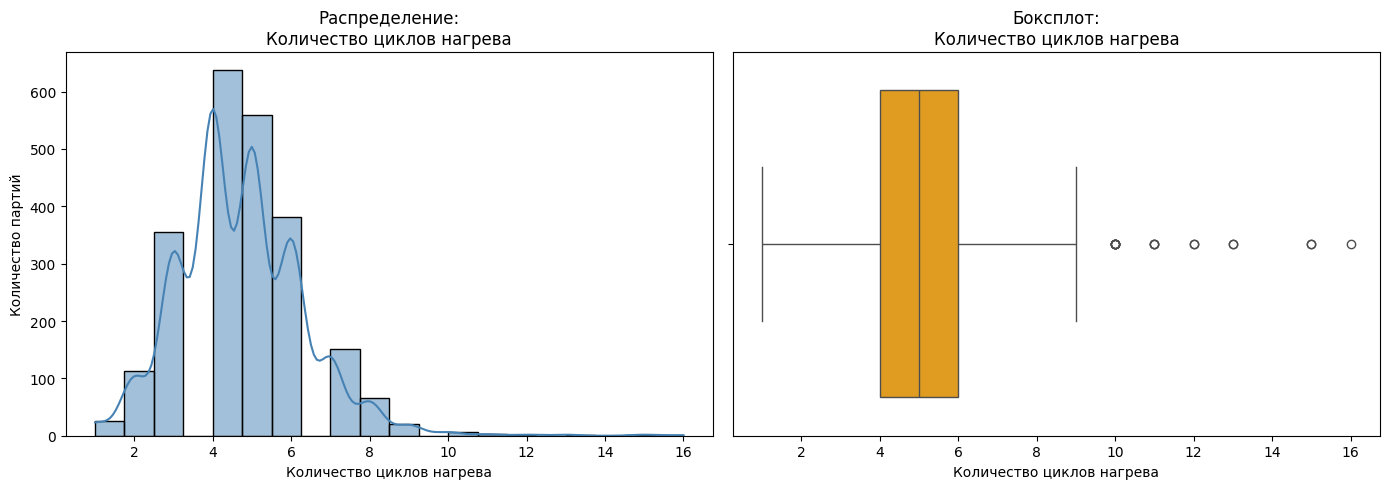

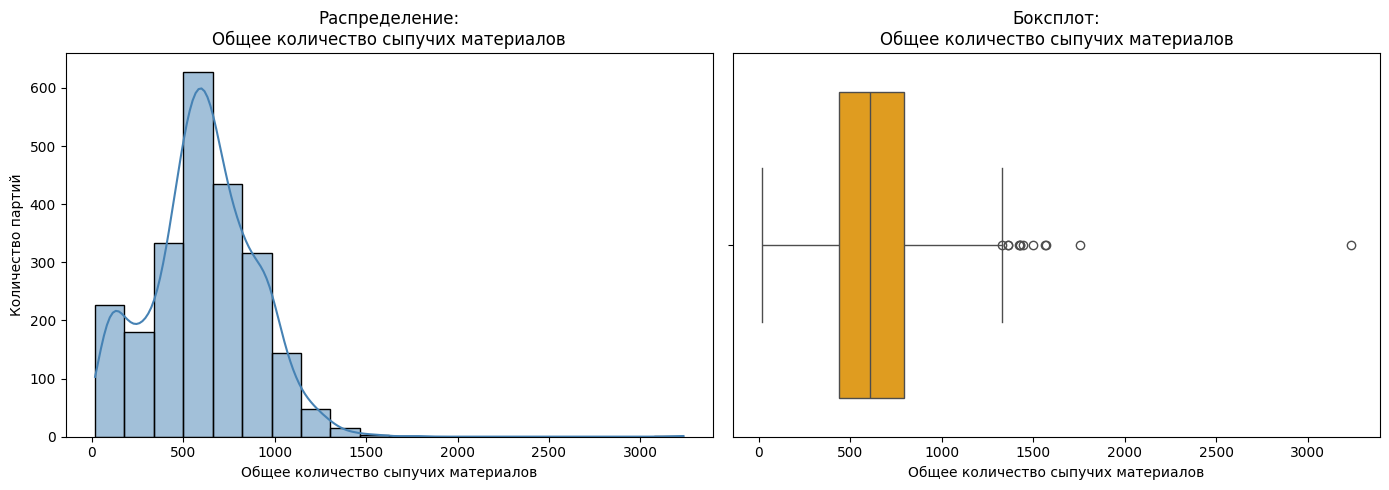

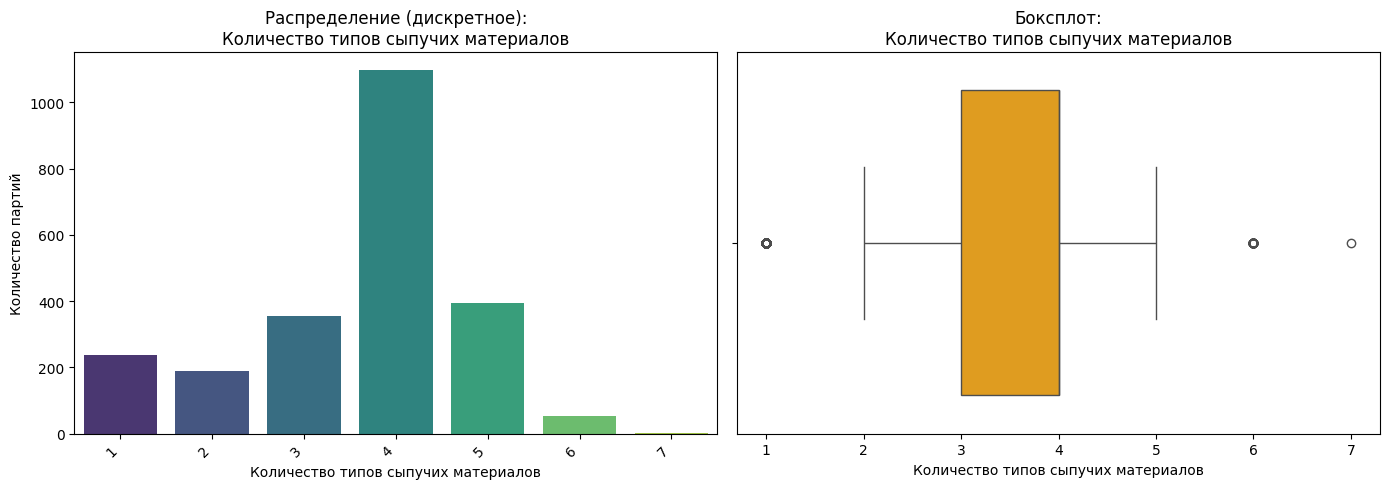

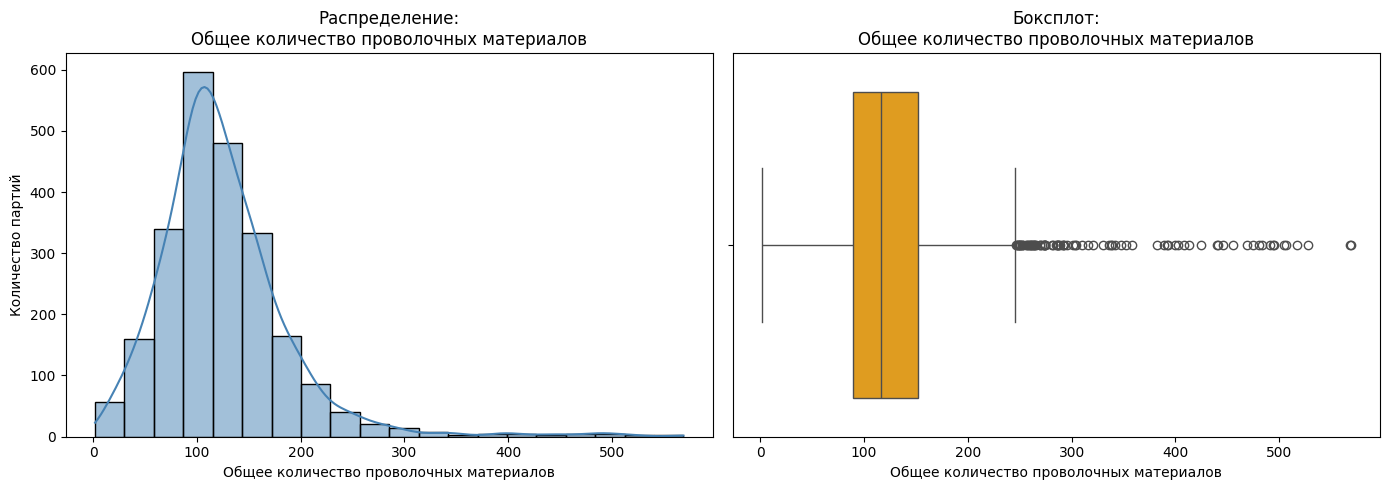

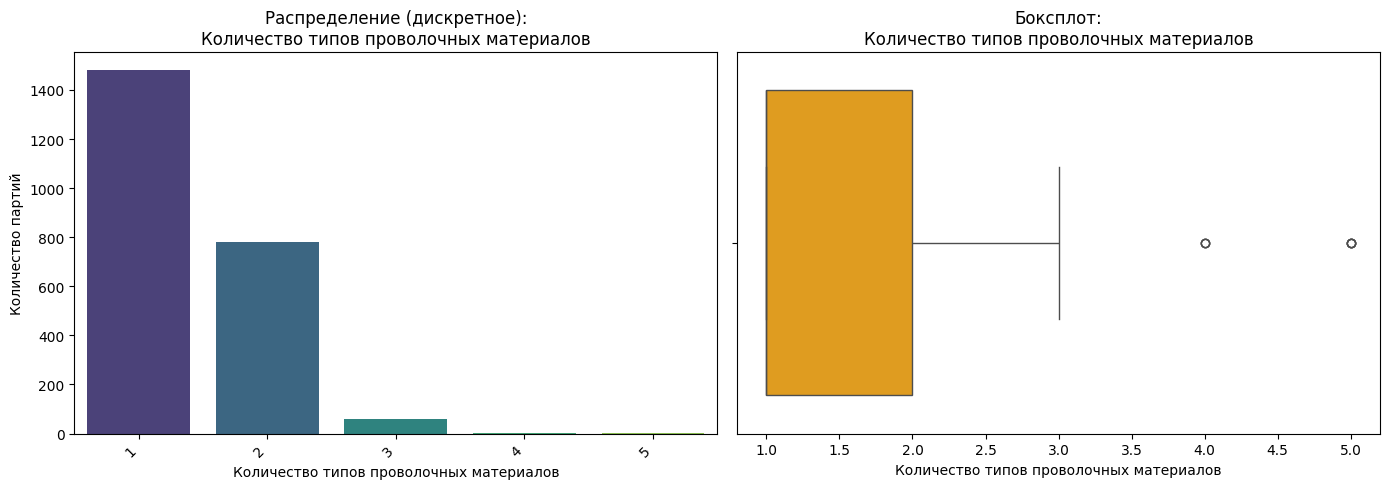

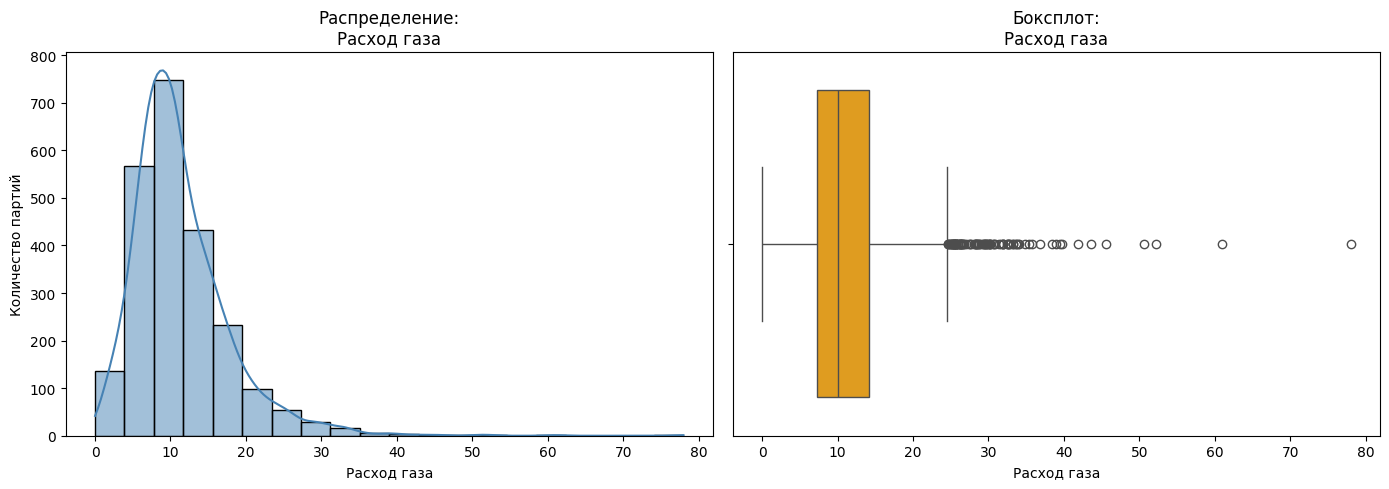

In [96]:
# Функция: является ли признак дискретным (в т.ч. float)
def is_discrete_feature(series, threshold=15):
    '''
    Проверяет признак на дискретность
    В том числе если тип данных float.
    Если данные имеют меньше 15 значений, то признак дискретный.
    '''
    return (
        series.nunique() < threshold and
        (is_integer_dtype(series) or series.dropna().apply(float.is_integer).all())
    )

# Словарь читаемых названий осей 
axis_labels = {
    'first_temp': 'Начальная температура партии (°C)',
    'last_temp': 'Конечная температура партии (целевая, °C)',
    'total_energy': 'Суммарная энергия нагрева (P × t)',
    'total_heating_time': 'Общее время нагрева (сек)',
    'mean_active_power': 'Средняя активная мощность',
    'mean_reactive_power': 'Средняя реактивная мощность',
    'mean_full_power': 'Средняя полная мощность',
    'mean_power_ratio': 'Соотношение активной к реактивной мощности',
    'heating_count': 'Количество циклов нагрева',
    'gas': 'Расход газа',
    'total_bulk': 'Общее количество сыпучих материалов',
    'bulk_types_count': 'Количество типов сыпучих материалов',
    'total_wire': 'Общее количество проволочных материалов',
    'wire_types_count': 'Количество типов проволочных материалов'
}

# Функция для построения графиков распределений ---
def plot_feature_distributions(df, num_cols=None):
    '''
    Строит распределения и боксплоты для числовых признаков набора данных.
    Для каждого числового признака создаёт два графика:
    1. Распределение (гистограмма или countplot для дискретных признаков)
    2. Боксплот для визуализации выбросов и разброса    
    
    '''
    num_cols = df.select_dtypes(include='number').columns
    num_cols = [col for col in num_cols if col in axis_labels.keys()]

    for col in num_cols:
        label = axis_labels.get(col, col)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        if is_discrete_feature(df[col]):
            sns.countplot(x=df[col], ax=axes[0], palette='viridis')
            axes[0].set_title(f'Распределение (дискретное):\n{label}')
            axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
            axes[0].set_xlabel(label)
            axes[0].set_ylabel('Количество партий')
        else:
            sns.histplot(df[col], bins=20, kde=True, ax=axes[0], color='steelblue')
            axes[0].set_title(f'Распределение:\n{label}')
            axes[0].set_xlabel(label)
            axes[0].set_ylabel('Количество партий')

        sns.boxplot(x=df[col], ax=axes[1], color='orange')
        axes[1].set_title(f'Боксплот:\n{label}')
        axes[1].set_xlabel(label)

        plt.tight_layout()
        plt.show()


plot_feature_distributions(data_agg, num_cols=process_cols)

Температуры (начальная и конечная):
- Небольшое количество крайних значений, но без экстремальных выбросов.
- Данные стабильные. Хороший признак.

Мощности (активная, реактивная, полная):
- Выбросы единичные и технологически объяснимые.
- распределения устойчивые, перекоса нет

Отношение P/Q:
- Узкий диапазон значений.
- Отсутствуют тяжёлые хвосты.

Общее время нагреваН:
- Длинный хвост (есть партии с существенно увеличенным временем).
- Требуется логарифмирование признака

Суммарная энергия нагрева (P × t):
- Наличие экстремальных значений.
- Требуется логарифмирование признака

Общее количество сыпучих материалов:
- Небольшое число партий с очень большим объёмом.
- Основная масса значений сосредоточена в умеренном диапазоне.
- Требуется логарифмирование признака

Общее количество проволочных материалов:
- Явные экстремальные партии.
- Требуется логарифмирование признака

Расход газа:
- Большинство партий в диапазоне 5–20.
- Небольшое число партий с очень большим расходом.
- Требуется логарифмирование признака

Таким образом, для более стабильной работы неиросетей необходимо логарифмирование таких признаков как: `total_heating_time`, `total_energy`, `total_bulk`, `total_wire`, `gas`

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>рабочитй подход) ОК.

### Корреляционный анализ

Изучим взаимосвязь между признаками. Для этого рассчитаем коэффициенты корреляции между признаками с помощью матрицы корреляции phik.
Для анализа я буду использовать только агрегированные и ключевые производственные признаки. Признаки bulk_i и wire_i сильно разряжены и поэтому будут малоинформативны в данном анализе.

In [97]:
bulk_cols = [col for col in data_agg.columns if 'bulk_' in col]
wire_cols = [col for col in data_agg.columns if 'wire_' in col]
time_cols = [col for col in data_agg.columns if 'addition' in col]
data_agg_corr = data_agg.drop(columns = ['key'] + bulk_cols + wire_cols + time_cols)
data_agg_corr.describe()

,first_temp,last_temp,total_heating_time,mean_heating_time,max_heating_time,mean_active_power,max_active_power,mean_reactive_power,mean_full_power,mean_power_ratio,total_energy,heating_count,total_bulk,total_wire,gas
count,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000
mean,1587.389605,1593.371993,807.808419,172.057939,289.689003,0.664104,0.967845,0.488890,0.825539,1.371462,539.107742,4.695876,609.748282,125.230004,11.375511
std,23.624276,11.198791,340.823100,43.731120,107.141535,0.128377,0.232057,0.097967,0.160341,0.065999,257.280972,1.606909,287.605102,63.688634,6.393413
min,1519.000000,1541.000000,57.000000,57.000000,57.000000,0.267676,0.267676,0.196228,0.331897,1.099589,26.187544,1.000000,19.000000,1.918800,0.008399
25%,1571.000000,1587.000000,581.000000,141.000000,212.000000,0.576159,0.801979,0.420039,0.714277,1.329124,368.187260,4.000000,440.000000,89.048700,7.282534
50%,1587.000000,1593.000000,778.000000,169.500000,277.000000,0.655834,0.972267,0.484669,0.818302,1.372071,508.260683,5.000000,609.000000,116.106121,10.100687
75%,1603.000000,1598.000000,993.000000,198.750000,339.000000,0.741641,1.157599,0.546539,0.921148,1.414713,678.508092,6.000000,795.250000,151.582857,14.216939
max,1660.000000,1653.000000,4189.000000,378.000000,907.000000,1.243889,1.463773,0.960763,1.572238,1.663366,3718.054401,16.000000,3235.000000,568.777664,77.995040


In [98]:
corr_pearson = data_agg_corr.corr()
corr_pearson

,first_temp,last_temp,total_heating_time,mean_heating_time,max_heating_time,mean_active_power,max_active_power,mean_reactive_power,mean_full_power,mean_power_ratio,total_energy,heating_count,total_bulk,total_wire,gas
first_temp,1.000000,0.301241,-0.384900,-0.438207,-0.401542,-0.008484,-0.063621,-0.003013,-0.006520,-0.028577,-0.346047,-0.178295,-0.112233,0.131464,0.036053
last_temp,0.301241,1.000000,0.278112,0.193440,0.229853,0.040140,0.068847,0.032878,0.037741,0.013398,0.258003,0.180640,0.222228,0.060630,0.059203
total_heating_time,-0.384900,0.278112,1.000000,0.560598,0.713742,0.050010,0.243839,0.043513,0.047971,0.021242,0.901737,0.798932,0.551608,0.091538,0.396497
mean_heating_time,-0.438207,0.193440,0.560598,1.000000,0.749103,0.035033,-0.002174,0.023048,0.030934,0.053219,0.506151,-0.002198,0.379175,-0.086710,0.102054
max_heating_time,-0.401542,0.229853,0.713742,0.749103,1.000000,0.036188,0.099648,0.033802,0.035626,0.014984,0.642558,0.335410,0.490534,-0.046376,0.236367
mean_active_power,-0.008484,0.040140,0.050010,0.035033,0.036188,1.000000,0.761829,0.965362,0.995391,0.002196,0.396768,0.033926,0.053162,0.025506,0.040258
max_active_power,-0.063621,0.068847,0.243839,-0.002174,0.099648,0.761829,1.000000,0.740290,0.760061,-0.018119,0.484303,0.311534,0.152333,0.065715,0.126496
mean_reactive_power,-0.003013,0.032878,0.043513,0.023048,0.033802,0.965362,0.740290,1.000000,0.985920,-0.239118,0.379186,0.032369,0.050817,0.030461,0.041628
mean_full_power,-0.006520,0.037741,0.047971,0.030934,0.035626,0.995391,0.760061,0.985920,1.000000,-0.086082,0.393469,0.033538,0.052645,0.027567,0.041076
mean_power_ratio,-0.028577,0.013398,0.021242,0.053219,0.014984,0.002196,-0.018119,-0.239118,-0.086082,1.000000,0.017626,-0.003379,0.004482,-0.018096,-0.005742


<div class="alert alert-danger" style="border-color: darkred; border-radius: 5px">
    <p><u><b>❌ КОММЕНТАРИЙ МЕНТОРА</b></u></p>отлично!!!! ЗАМЕЧУ один важный момент по корреляционному анализу. По умолчанию применяется метод корреляции Пирсона. А он подходит только для нормального распределения. Если распределение ненормальное, то иной метод нужен - Спирмена или Кендала. У нас данные больше тяготеют к ненормальному распределени. Посомтри этот момент ещё раз)

<div class="alert alert-info">
<b>Комментарий студента:</b> Исправлено. Добавила анализ по Спирмена.
</div>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-success" style="border-color: green; border-radius: 5px">
<b> КОММЕНТАРИЙ МЕНТОРА 2</b><br>ок, есть контакт)

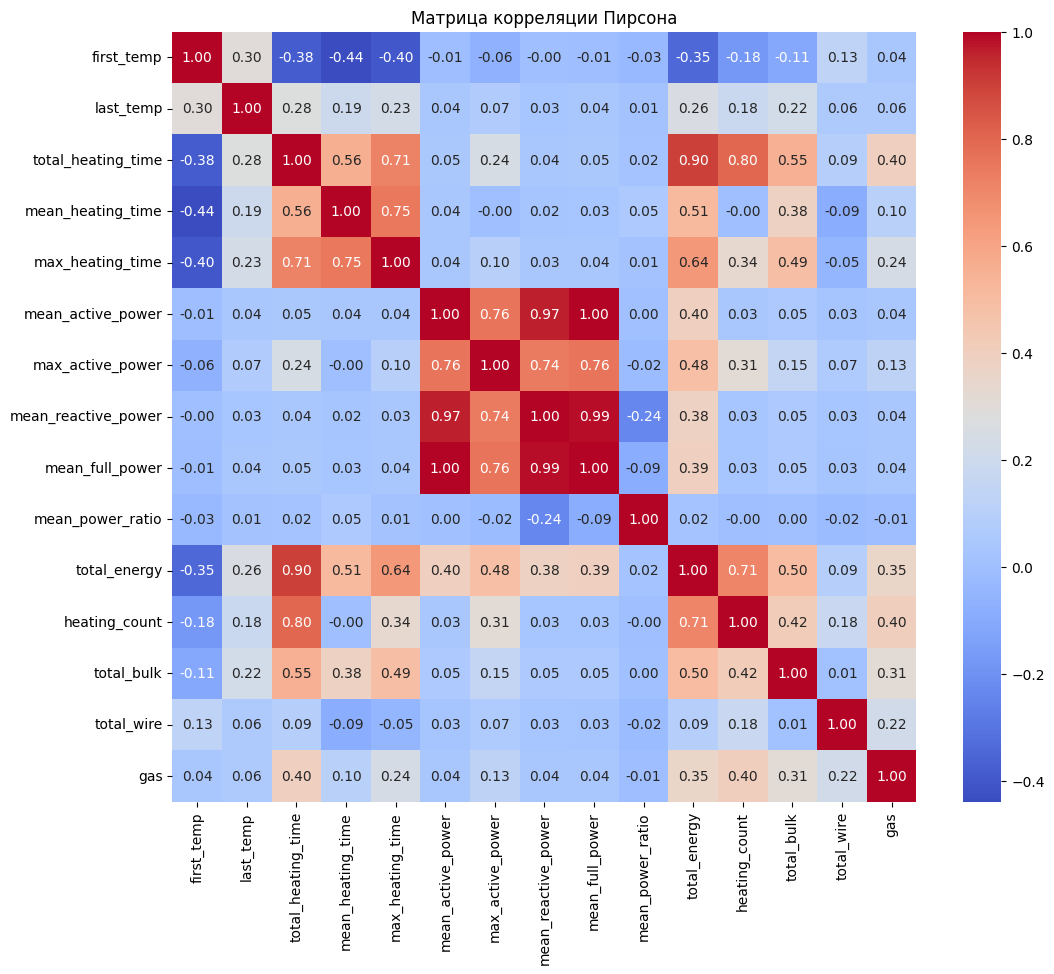

In [101]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляции Пирсона')
plt.show()

<b>Анализ корреляции Пирсона</b>

Между признаками мощности наблюдается очень высокая корреляция:
- `mean_active_power` — `mean_full_power` ≈ 1
- `mean_active_power` — `mean_reactive_power` ≈ 0.97 
- `mean_reactive_power` — `mean_full_power` ≈ 0.99

Это объясняется тем, что данные признаки отражают разные характеристики одного и того же процесса подачи электрической энергии.

Сильная положительная корреляция наблюдается между характеристиками нагрева:
- `total_heating_time` — `total_energy` ≈ 0.9
- `total_heating_time` — `heating_count` ≈ 0.8
- `total_heating_time` — `mean_heating_time` ≈ 0.75

Это говорит о том, что увеличение времени нагрева приводит к росту энергопотребления и количества циклов нагрева.

Начальная температура имеет отрицательную корреляцию с параметрами нагрева:
- `first_temp` — `total_heating_time` ≈ -0.38
- `first_temp` — `mean_heating_time` ≈ -0.44

Это означает, что при более высокой начальной температуре требуется меньше времени для достижения нужной температуры плавки.     

Наиболее сильная мультиколлинеарность наблюдается между показателями мощности:
- `mean_active_power`
- `mean_reactive_power`
- `mean_full_power`

Поскольку `mean_full_power` фактически представляет собой агрегированную характеристику мощности, включающую активную и реактивную составляющие, использование всех трёх признаков может приводить к избыточности информации. В связи с этим из набора признаков целесообразно удалить `mean_full_power`

Так как данные у нас имеют выбросы, ассиметрию, и нелинейные зависимости, дополнительно необходимо посмотреть корреляцию Спирмена.

In [102]:
corr_spearman = data_agg_corr.corr(method='spearman')
corr_spearman

,first_temp,last_temp,total_heating_time,mean_heating_time,max_heating_time,mean_active_power,max_active_power,mean_reactive_power,mean_full_power,mean_power_ratio,total_energy,heating_count,total_bulk,total_wire,gas
first_temp,1.000000,0.307590,-0.418989,-0.444626,-0.422094,-0.017608,-0.064118,-0.010083,-0.015123,-0.038721,-0.378968,-0.185285,-0.100669,0.175265,0.031265
last_temp,0.307590,1.000000,0.236578,0.160862,0.190093,0.048960,0.072968,0.043231,0.047105,-0.003208,0.221060,0.170953,0.215744,0.110498,0.043152
total_heating_time,-0.418989,0.236578,1.000000,0.589384,0.734045,0.063791,0.233255,0.057848,0.061858,0.017610,0.885692,0.772787,0.524330,0.085755,0.376601
mean_heating_time,-0.444626,0.160862,0.589384,1.000000,0.761305,0.041150,-0.004280,0.031941,0.038254,0.040527,0.525914,-0.000852,0.368187,-0.106950,0.090538
max_heating_time,-0.422094,0.190093,0.734045,0.761305,1.000000,0.040584,0.091866,0.039008,0.040568,0.013100,0.646765,0.338641,0.467095,-0.046248,0.224834
mean_active_power,-0.017608,0.048960,0.063791,0.041150,0.040584,1.000000,0.766534,0.963750,0.995166,-0.003426,0.441675,0.053107,0.065539,0.022147,0.055489
max_active_power,-0.064118,0.072968,0.233255,-0.004280,0.091866,0.766534,1.000000,0.743457,0.764236,-0.024905,0.510267,0.300651,0.142862,0.070273,0.142690
mean_reactive_power,-0.010083,0.043231,0.057848,0.031941,0.039008,0.963750,0.743457,1.000000,0.985050,-0.228023,0.423326,0.054025,0.060080,0.026744,0.058579
mean_full_power,-0.015123,0.047105,0.061858,0.038254,0.040568,0.995166,0.764236,0.985050,1.000000,-0.084603,0.438056,0.053343,0.063966,0.024156,0.056771
mean_power_ratio,-0.038721,-0.003208,0.017610,0.040527,0.013100,-0.003426,-0.024905,-0.228023,-0.084603,1.000000,0.015754,-0.009320,0.014436,-0.003263,-0.004287


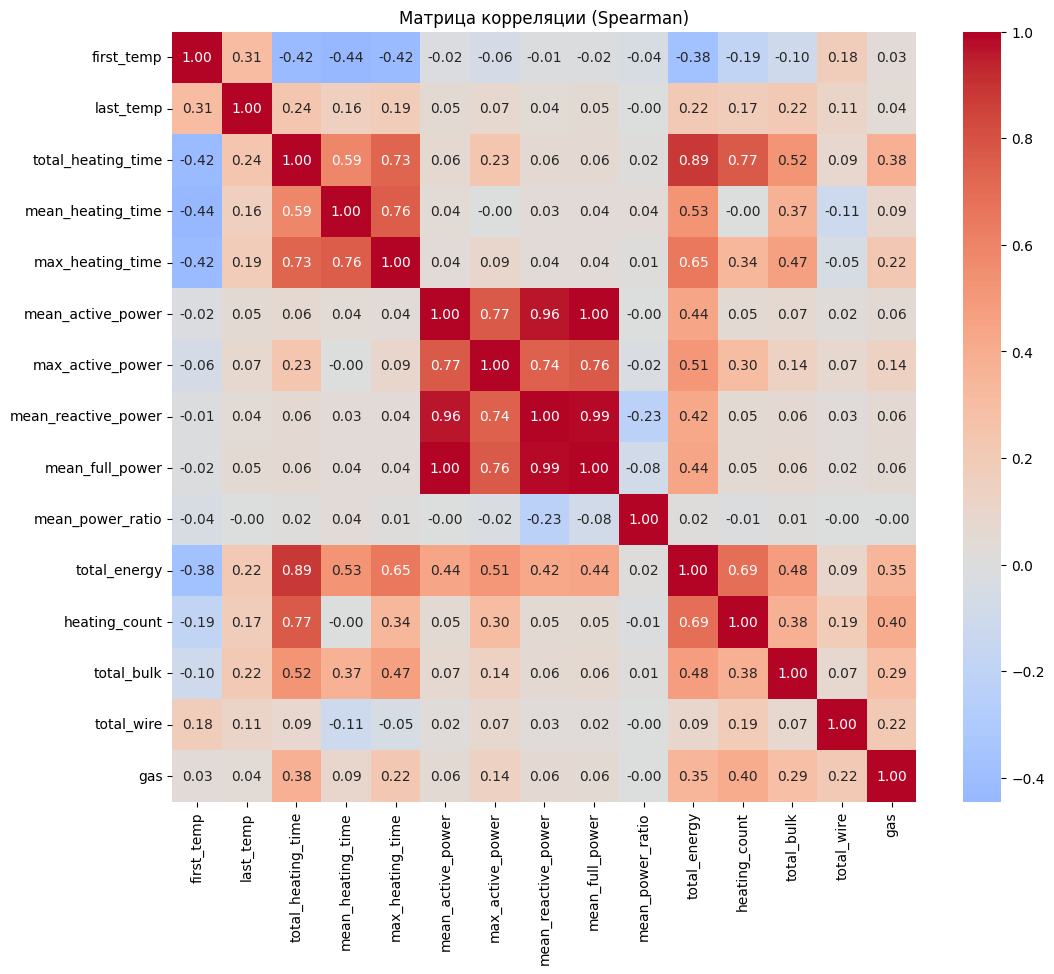

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляции (Spearman)')
plt.show()

<b>Анализ корреляции Спирмена</b>

Матрица корреляции Спирмена показала схожую структуру зависимостей между признаками.                              
Основные группы сильных зависимостей сохраняются:
- высокая связь между показателями мощности;
- сильная зависимость между временем нагрева и потреблением энергии;
- отрицательная связь между начальной температурой и длительностью нагрева.

Корреляционный анализ показал, что наибольшая линейная связь с таргетом (`last_temp`) наблюдается у начальной температуры, а также у суммарного времени нагрева и общей энергии процесса, что физически логично — чем выше старт и больше затрачено энергии, тем выше итоговая температура. 
Явных признаков утечки целевой переменной не обнаружено. взаимосвязи между производственными признаками отражают технологическую природу процесса.        

In [103]:
data_agg = data_agg.drop(columns=['mean_full_power'])
data_agg.shape

(2328, 95)

<div class="alert alert-warning" style="border-color: darkorange; border-radius: 5px">
    <p><u><b>⚠️ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
аргументация понятна. Но я бы удалял мультиколлинеарность. Дело не просто в математических методах, которые нивелируют негатив от высокой корреляции факторов. Просто если два фактора сильны связаны, то они примеро идентично влияют на целевую и от одно из них смело можно избавляться - метрика сильно хуже не будет. А вот сама модель будет "по легче", т.к. будет меньше факторов.

<div class="alert alert-info">
<b>Комментарий студента:</b> Исправлено.
</div>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-success" style="border-color: green; border-radius: 5px">
<b> КОММЕНТАРИЙ МЕНТОРА 2</b><br>ок

### Log признаки

In [104]:
# Признаки для логарифмирования
skewed_features = ['total_heating_time', 'total_energy', 'total_bulk', 'total_wire', 'gas']

# Создаём новые признаки с логарифмом
for col in skewed_features:
    data_agg[f'log_{col}'] = np.log1p(data_agg[col])   # log1p = log(1 + x), чтобы избежать log(0)
print('Созданы лог-признаки:', [f'log_{c}' for c in skewed_features])

Созданы лог-признаки: ['log_total_heating_time', 'log_total_energy', 'log_total_bulk', 'log_total_wire', 'log_gas']


### Подготовка данных для обучения

У меня есть временные признаки, которые не сможет корректно обработать модель, с другой стороны они не дают нам много полезной информации - факт подачи материала отражен в столбцах bulk_i и wire_i, а addition_span фактически связан с временем нагрева. Поэтому я удаляю признаки datetime из модели.

<div class="alert alert-warning" style="border-color: darkorange; border-radius: 5px">
    <p><u><b>⚠️ КОММЕНТАРИЙ МЕНТОРА</b></u></p>я бы итакие факторы не использовал() слишком много поучается. На практике тяжело такие модели использовать для прогнозирования. Есть такое внегласное правило: лучше та модель, которая при прочих равных имеет меньшее количество факторов.

<div class="alert alert-info">
<b>Комментарий студента:</b> Исправлено.
</div>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-success" style="border-color: green; border-radius: 5px">
<b> КОММЕНТАРИЙ МЕНТОРА 2</b><br>увидел. Но можно ещё меньше факторов в итоге) Но это уже на исследование после.

In [105]:
data_agg = data_agg.drop(columns=['first_addition', 'first_addition_wire', 'last_addition', 'last_addition_wire' , 'addition_span', 'addition_span_wire'])

In [106]:
time_cols = data_agg.select_dtypes(include=['datetime64[ns]']).columns.tolist()
time_cols

['bulk_1_time',
 'bulk_2_time',
 'bulk_3_time',
 'bulk_4_time',
 'bulk_5_time',
 'bulk_6_time',
 'bulk_7_time',
 'bulk_8_time',
 'bulk_9_time',
 'bulk_10_time',
 'bulk_11_time',
 'bulk_12_time',
 'bulk_13_time',
 'bulk_14_time',
 'bulk_15_time',
 'wire_1_time',
 'wire_2_time',
 'wire_3_time',
 'wire_4_time',
 'wire_5_time',
 'wire_6_time',
 'wire_7_time',
 'wire_8_time',
 'wire_9_time']

In [ ]:
data_agg = data_agg.drop(columns=time_cols)
data_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2328 entries, 0 to 2327
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   key                     2328 non-null   int64  
 1   first_temp              2328 non-null   float64
 2   last_temp               2328 non-null   float64
 3   total_heating_time      2328 non-null   float64
 4   mean_heating_time       2328 non-null   float64
 5   max_heating_time        2328 non-null   float64
 6   mean_active_power       2328 non-null   float64
 7   max_active_power        2328 non-null   float64
 8   mean_reactive_power     2328 non-null   float64
 9   mean_power_ratio        2328 non-null   float64
 10  total_energy            2328 non-null   float64
 11  heating_count           2328 non-null   int64  
 12  bulk_1                  2328 non-null   float64
 13  bulk_2                  2328 non-null   float64
 14  bulk_3                  2328 non-null   

In [108]:
X = data_agg.drop(['last_temp','key'], axis=1)
y = data_agg['last_temp']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

Данные разделены и готовы для обучения.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>и кей удаляем, согласен.

## Обучение моделей

### BaseLine модель

В качестве baseline-модели я использую DummyRegressor — самую простую модель, которая всегда предсказывает одно и то же значение (например, медиану температуры).

Она нужна для того, чтобы задать минимальный ориентир качества. Любая обучаемая модель должна показывать результат лучше, чем dummy. Если этого не происходит, значит в данных нет полезного сигнала или есть проблемы в подготовке признаков.

In [109]:
X = data_agg.drop(columns=['last_temp','key'])
y = data_agg['last_temp']

# 1) Dummy baseline: mean
dummy_mean = DummyRegressor(strategy='mean')
cv_mae_mean = -cross_val_score(dummy_mean, X, y, cv=3, scoring='neg_mean_absolute_error').mean()

# 2) Dummy baseline: median
dummy_median = DummyRegressor(strategy='median')
cv_mae_median = -cross_val_score(dummy_median, X, y, cv=3, scoring='neg_mean_absolute_error').mean()

print(f'Dummy(mean)   CV MAE: {cv_mae_mean:.3f}')
print(f'Dummy(median) CV MAE: {cv_mae_median:.3f}')

Dummy(mean)   CV MAE: 8.118
Dummy(median) CV MAE: 8.076


### Случайный лес и бустинги

Для учёта нелинейных зависимостей буду использовать случайный лес — классический ансамблевый алгоритм. Далее были выбрала современные бустинговые модели: LightGBM и CatBoost, которые обыно хорошо работают с числовыми данными. Такой набор обеспечивает сравнение базовых и продвинутых решений, что позволяет объективно выбрать оптимальную модель.

Для максимального результата я буду использовать SelectKbest.

In [110]:
# --- Только числовые признаки ---
num_cols = X_train.columns.tolist()

preprocessor_num = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='constant', fill_value=0), num_cols)
    ],
    remainder='drop'
)

models = {
    'RandomForest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostRegressor(
        random_state=RANDOM_STATE,
        verbose=0,
        loss_function='MAE',
        allow_writing_files=False
    )
}

param_distributions = {
    'RandomForest': {
        'select__k': randint(10, len(num_cols)), 
        'model__n_estimators': randint(50, 200),
        'model__max_depth': randint(5, 20),
        'model__min_samples_split': randint(2, 10),
        'model__min_samples_leaf': randint(1, 6),
    },
    'LightGBM': {
        'select__k': randint(10, len(num_cols)),
        'model__n_estimators': randint(100, 800),
        'model__max_depth': randint(3, 15),
        'model__learning_rate': uniform(0.01, 0.2),
        'model__num_leaves': randint(16, 256),
    },
    'CatBoost': {
        'select__k': randint(10, len(num_cols)),
        'model__iterations': randint(200, 1200),
        'model__depth': randint(4, 11),
        'model__learning_rate': uniform(0.01, 0.2),
    }
}

results = []
best_estimators = {}

for name, model in models.items():
    print(f'\n🔹 Обучаем {name}...')

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_num),
        ('select', SelectKBest(score_func=f_regression)), 
        ('model', model)
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions[name],
        n_iter=10,
        scoring='neg_mean_absolute_error',
        cv=5,
        verbose=1,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

    start = time.time()
    search.fit(X_train, y_train)
    train_time = time.time() - start

    results.append({
        'Model': name,
        'CV_MAE': -search.best_score_,
        'Train_Time (s)': round(train_time, 2),
        'Best_Params': search.best_params_
    })

    best_estimators[name] = search.best_estimator_

results_df = pd.DataFrame(results).sort_values('CV_MAE')
print('\nИтоговое сравнение моделей:')
results_df


🔹 Обучаем RandomForest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

🔹 Обучаем LightGBM...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

🔹 Обучаем CatBoost...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Итоговое сравнение моделей:


,Model,CV_MAE,Train_Time (s),Best_Params
0,RandomForest,6.331752,45.77,"{'model__max_depth': 17, 'model__min_samples_l..."
2,CatBoost,6.333693,434.07,"{'model__depth': 5, 'model__iterations': 483, ..."
1,LightGBM,6.420374,77.36,"{'model__learning_rate': 0.02158153778388378, ..."


Лучшая модель по CV RandomFores, метрика на СV_MAE = 6.33.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>верно. на трайне изучаем, и кросс-валидированную метрику выводим. Принято

### Нейронные сети

Для начала сделаю простую нейросеть без drop и datch.

In [111]:
# Фиксируем сиды
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Для обучения нейронной сети обучающая выборка была дополнительно разделена на обучающую и валидационную части. Валидационная выборка использовалась для контроля обучения и ранней остановки.

In [114]:
X_train_, X_val, y_train_, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [115]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_num)
])
# Преобразуем данные
X_train_transformed = pipeline.fit_transform(X_train_)
X_val_transformed   = pipeline.transform(X_val)
X_test_transformed  = pipeline.transform(X_test)

# Tensor'ы X
X_train_t = torch.tensor(X_train_transformed, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_transformed,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_transformed,  dtype=torch.float32)

# Скейлер для y (учим только на train_)
y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train_.values.reshape(-1, 1))
y_val_s   = y_scaler.transform(y_val.values.reshape(-1, 1))
y_test_s  = y_scaler.transform(y_test.values.reshape(-1, 1))

# Tensor'ы y
y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
y_val_t   = torch.tensor(y_val_s,   dtype=torch.float32)
y_test_t  = torch.tensor(y_test_s,  dtype=torch.float32)

input_dim = X_train_t.shape[1]

In [116]:
# Модель
class TempNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),
            
            nn.Linear(512, 512),
            nn.ReLU(),
            
            nn.Linear(512, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.model(x)

In [117]:
def train_model(
    X_train_t, y_train_t, 
    X_val_t, y_val_t, 
    y_scaler,
    lr=1e-3,
    input_dim=input_dim,
    max_epochs=2000,
    patience=400
):
    model = TempNN(X_train_t.shape[1])
    criterion = nn.L1Loss()
    optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        factor=0.6,
        patience=47
    )

    best_mae = float('inf')
    best_state = None
    wait = 0

    train_losses = []
    val_losses = []
    val_mae = []

    for epoch in range(1, max_epochs + 1):

        # TRAIN
        model.train()
        optimizer.zero_grad()

        pred_train = model(X_train_t)
        loss_train = criterion(pred_train, y_train_t)
        loss_train.backward()
        optimizer.step()

        # VALID
        model.eval()
        with torch.no_grad():
            pred_val = model(X_val_t)
            loss_val = criterion(pred_val, y_val_t).item()

            pred_val_real = y_scaler.inverse_transform(pred_val.numpy()).ravel()
            y_val_real   = y_scaler.inverse_transform(y_val_t.numpy()).ravel()

            mae_val = mean_absolute_error(y_val_real, pred_val_real)

        train_losses.append(loss_train.item())
        val_losses.append(loss_val)
        val_mae.append(mae_val)
        scheduler.step(mae_val)

        if mae_val < best_mae:
            best_mae = mae_val
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1

        if epoch % 50 == 0:
            print(f'Epoch {epoch}/{max_epochs} | '
                  f'train={loss_train:.4f} | val={loss_val:.4f} | '
                  f'val_MAE={mae_val:.2f}')
        if wait >= patience:
            print(f'\nEarly stopping! Лучший MAE={best_mae:.2f}')
            break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses, val_mae, best_mae

In [118]:
model, train_losses, val_losses, val_mae, best_mae = train_model(
    X_train_t, y_train_t,
    X_val_t,  y_val_t,
    y_scaler,
    lr=1e-3,
    max_epochs=1000,
    patience=200
)

print(f'\nЛучший MAE: {best_mae:.2f}')
# Предсказание и расчет MAE 
model.eval()
with torch.no_grad():
    y_pred_s = model(X_val_t).numpy()  # стандартизированный прогноз

y_pred = y_scaler.inverse_transform(y_pred_s).ravel() 
mae = mean_absolute_error(y_val, y_pred)
print(f'\n MAE на валидационной выборке: {mae:.2f}')

Epoch 50/1000 | train=0.7452 | val=0.8271 | val_MAE=9.42
Epoch 100/1000 | train=0.7940 | val=0.7394 | val_MAE=8.42
Epoch 150/1000 | train=0.6274 | val=0.7522 | val_MAE=8.57
Epoch 200/1000 | train=0.6047 | val=0.6755 | val_MAE=7.69
Epoch 250/1000 | train=0.6631 | val=0.6708 | val_MAE=7.64
Epoch 300/1000 | train=0.4931 | val=0.6953 | val_MAE=7.92
Epoch 350/1000 | train=0.4570 | val=0.6912 | val_MAE=7.87
Epoch 400/1000 | train=0.4214 | val=0.6883 | val_MAE=7.84

Early stopping! Лучший MAE=7.50

Лучший MAE: 7.50

 MAE на валидационной выборке: 7.87


<div class="alert alert-warning" style="border-color: darkorange; border-radius: 5px">
    <p><u><b>⚠️ КОММЕНТАРИЙ МЕНТОРА</b></u></p>всё же правильнее тестовую выборку не использовать на обучении. Только при окончательном тестировании. В нейронке используют подход - разбивают трайн на трайн и валид.

<div class="alert alert-info">
<b>Комментарий студента:</b> Исправлено.
</div>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-success" style="border-color: green; border-radius: 5px">
<b> КОММЕНТАРИЙ МЕНТОРА 2</b><br>увидел, ок

Прогноз получился на уровне дамми модели. 

Попробую улучшить сеть.                           
Добавлю перебор по батчам и dropouts, перебор по скорости обучения делать не буду в виду ограниченных ресурсов.
Нейросеть будет обучаться с функцией потерь MSE, так как она гладкая и даёт более стабильные градиенты, что обычно ускоряет и стабилизирует обучение. Качество моделей при этом сравнивается по MAE.

In [119]:
set_seed(42)
def train_model_new(
    X_train_t, y_train_t,
    X_val_t,   y_val_t,
    y_scaler,
    input_dim,
    dropout=0.0,
    batch_size=None,
    lr=1e-3,
    max_epochs=1000,
    patience=200
):

    # Модель с параметром dropout 
    class TempNN_Drop(nn.Module):
        def __init__(self, input_dim, dropout=0.0):
            super().__init__()
            self.model = nn.Sequential(
                nn.Linear(input_dim, 256),
                nn.ReLU(),
                nn.Dropout(dropout),

                nn.Linear(256, 512),
                nn.ReLU(),
                nn.Dropout(dropout),

                nn.Linear(512, 512),
                nn.ReLU(),
                nn.Dropout(dropout),

                nn.Linear(512, 64),
                nn.ReLU(),
                nn.Dropout(dropout),

                nn.Linear(64, 1)
            )

        def forward(self, x):
            return self.model(x)

    # создаём модель
    model = TempNN_Drop(input_dim, dropout=dropout)

    # функция потерь и оптимизатор
    criterion = nn.MSELoss()
    optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        factor=0.6,
        patience=50
    )

    best_mae = float('inf')
    best_state = None
    wait = 0

    train_losses = []
    val_losses = []
    val_mae = []
    r2_scores = []

    # ОБУЧЕНИЕ ПО ЭПОХАМ
    for epoch in range(1, max_epochs + 1):

        model.train()

        if batch_size is None:
            # обучение на всей выборке
            optimizer.zero_grad()
            preds = model(X_train_t)
            loss = criterion(preds, y_train_t)
            loss.backward()
            optimizer.step()
            train_loss = loss.item()

        else:
            # обучение батчами
            order = np.random.permutation(len(X_train_t))
            batch_losses = []
            for i in range(0, len(X_train_t), batch_size):
                batch_idx = order[i:i+batch_size]
                X_batch = X_train_t[batch_idx]
                y_batch = y_train_t[batch_idx]

                optimizer.zero_grad()
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer.step()

                batch_losses.append(loss.item())

            train_loss = np.mean(batch_losses)

        # ВАЛИДАЦИЯ
        model.eval()
        with torch.no_grad():
            # предсказания в тензоре
            val_pred_s = model(X_val_t)

            # val MSE в том же масштабе, что y_val_t
            val_loss = criterion(val_pred_s, y_val_t).item()

            # MAE и R2 в реальных градусах
            val_pred_real = y_scaler.inverse_transform(val_pred_s.cpu().numpy()).ravel()
            val_real = y_scaler.inverse_transform(y_val_t.cpu().numpy()).ravel()

            mae_val = mean_absolute_error(val_real, val_pred_real)
            r2 = r2_score(val_real, val_pred_real)
           
        # логирование
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_mae.append(mae_val)
        r2_scores.append(r2)

        # обновление LR
        scheduler.step(mae_val)

        # ранняя остановка
        if mae_val < best_mae:
            best_mae = mae_val
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1

        # лог каждые 50 эпох
       # if epoch % 200 == 0 or epoch == 1:
        #    print(f'Epoch {epoch}/{max_epochs} | Loss={train_loss:.4f} | MAE={mae_val:.2f} | LR={optimizer.param_groups[0]['lr']:.1e}')

        if wait >= patience:
            print(f'\nEarly stopping — лучшая эпоха {epoch - wait}, MAE={best_mae:.2f}')
            break

    # восстанавливаем лучшую модель
    model.load_state_dict(best_state)

    return model, train_losses, val_losses, val_mae, best_mae, r2_scores

In [120]:
input_dim = X_train_t.shape[1] 
dropouts = [0.2, 0.3, 0.4]
batch_sizes = [32, 64, 128]

results = []

for d in dropouts:
    for b in batch_sizes:

        print(f'\n=== Dropout={d}, Batch={b} ===')
        set_seed(42)
        model, train_losses, val_losses, val_mae, best_mae, r2_scores = train_model_new(
            X_train_t, y_train_t,
            X_val_t,  y_val_t,
            y_scaler=y_scaler,
            input_dim=input_dim,
            dropout=d,
            batch_size=b,
            lr=1e-3,
            max_epochs=1000,
            patience=200
        )

        results.append({
            'LR': 1e-3,
            'Dropout': d,
            'Batch': b,
            'MAE': best_mae,
            'R2': r2_scores[-1]
        })

        print(f'MAE = {best_mae:.2f}')

# таблица результатов
results_nn = pd.DataFrame(results).sort_values('MAE')
results_nn


=== Dropout=0.2, Batch=32 ===

Early stopping — лучшая эпоха 68, MAE=7.31
MAE = 7.31

=== Dropout=0.2, Batch=64 ===

Early stopping — лучшая эпоха 122, MAE=7.31
MAE = 7.31

=== Dropout=0.2, Batch=128 ===

Early stopping — лучшая эпоха 121, MAE=7.35
MAE = 7.35

=== Dropout=0.3, Batch=32 ===

Early stopping — лучшая эпоха 122, MAE=7.48
MAE = 7.48

=== Dropout=0.3, Batch=64 ===

Early stopping — лучшая эпоха 196, MAE=7.53
MAE = 7.53

=== Dropout=0.3, Batch=128 ===

Early stopping — лучшая эпоха 103, MAE=7.41
MAE = 7.41

=== Dropout=0.4, Batch=32 ===

Early stopping — лучшая эпоха 88, MAE=7.30
MAE = 7.30

=== Dropout=0.4, Batch=64 ===

Early stopping — лучшая эпоха 121, MAE=7.44
MAE = 7.44

=== Dropout=0.4, Batch=128 ===

Early stopping — лучшая эпоха 423, MAE=7.45
MAE = 7.45


,LR,Dropout,Batch,MAE,R2
6,0.001,0.4,32,7.298848,0.078848
1,0.001,0.2,64,7.306967,-0.046452
0,0.001,0.2,32,7.307287,0.006131
2,0.001,0.2,128,7.352446,0.093079
5,0.001,0.3,128,7.405486,0.118424
7,0.001,0.4,64,7.435231,0.072541
8,0.001,0.4,128,7.451623,0.091390
3,0.001,0.3,32,7.481252,-0.008266
4,0.001,0.3,64,7.534284,0.001083


Лучший результат нейронной модели МАЕ 7.3, однако R2 на уровне случайного угадывания.

## Тестирование модели

Лучшая модель -  RandomFores, метрика на СV_MAE = 6.33. Посмоторим метрику на тесте.

In [122]:
# --- Лучшая модель ---
best_row = results_df.iloc[0]
best_name = best_row['Model']
best_model = best_estimators[best_name]

print(f'\nЛучшая модель: {best_name} (CV_MAE={best_row['CV_MAE']:.2f})')

# --- Финальная проверка на тесте ---
y_pred_test = best_model.predict(X_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f'\nMAE на тестовой выборке ({best_name}): {mae_test:.2f}')
print(f'R² на тестовой выборке ({best_name}): {r2:.2f}')


Лучшая модель: RandomForest (CV_MAE=6.33)

MAE на тестовой выборке (RandomForest): 6.13
R² на тестовой выборке (RandomForest): 0.42


<div class="alert alert-warning" style="border-color: darkorange; border-radius: 5px">
    <p><u><b>⚠️ КОММЕНТАРИЙ МЕНТОРА</b></u></p>тестим лучшую, согласен. Но ведь ещё не все модели - нейронка вппереди. Лучшую выбираем из всех!

<div class="alert alert-info">
<b>Комментарий студента:</b> Исправлено. Переделала структуру. Финальный тест делаем только на лучшей подели.
</div>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-success" style="border-color: green; border-radius: 5px">
<b> КОММЕНТАРИЙ МЕНТОРА 2</b><br>принято

Модель ошибается примерно на 6 градусов в прогнозе и может объяснить 42% вариаций конечной температуры. Это намного лучше baseline модели.

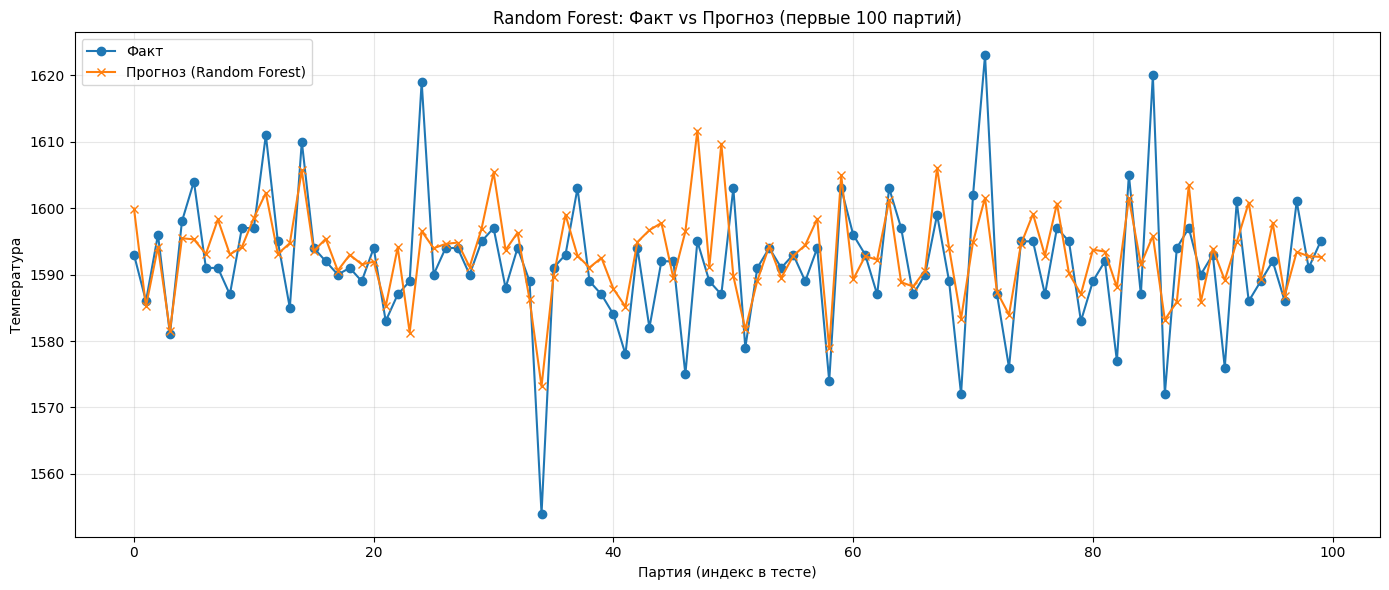

In [124]:
randomforest_pipeline = best_estimators[best_name]

y_pred = randomforest_pipeline.predict(X_test)

n = 100
y_true_100 = y_test.iloc[:n].values
y_pred_100 = y_pred[:n]

plt.figure(figsize=(14,6))
plt.plot(y_true_100, label='Факт', marker='o')
plt.plot(y_pred_100, label='Прогноз (Random Forest)', marker='x')
plt.title('Random Forest: Факт vs Прогноз (первые 100 партий)')
plt.xlabel('Партия (индекс в тесте)')
plt.ylabel('Температура')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

В целом видно, что модель хорошо повторяет общую динакимку. Иногда модель немного занижает или сглаживает резкие скачки температуры, но в большинстве случаев линии расположены близко к друг другу.

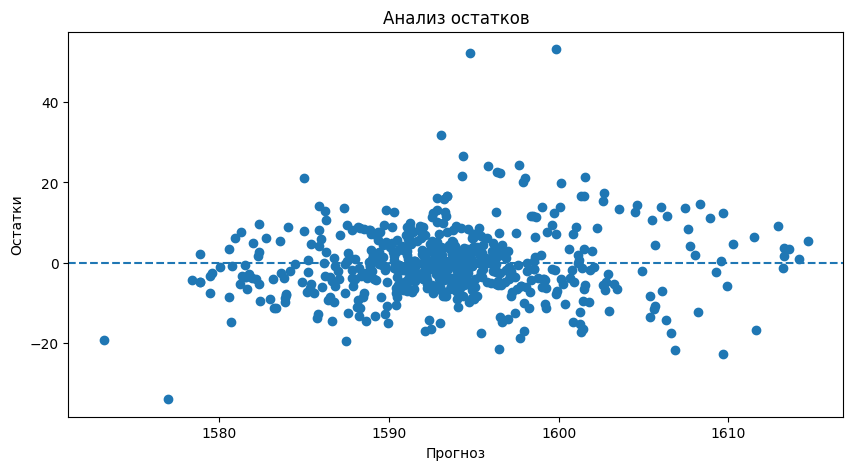

In [125]:
residuals = y_test - y_pred

plt.figure(figsize=(10,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel('Прогноз')
plt.ylabel('Остатки')
plt.title('Анализ остатков')
plt.show()

Ошибки модели распределены вокруг 0 и не имеют выраженной закономерности. Модель систематически завышает или занижает температуру. Основная часть ошибок находится в пределах +- 20 градусов, хотя встречаются отдельные выбросы. В целом модель достаточно хорошо описывает данные.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>визуальный осмотр). Но также ещё хорошо бы проводить аналитику остактков.

<div class="alert alert-info">
<b>Комментарий студента:</b> добавила.
</div>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-success" style="border-color: green; border-radius: 5px">
<b> КОММЕНТАРИЙ МЕНТОРА 2</b><br>верно, проверяем на гетероскедастичность. Можно ещё гистограмму глянуть.

In [126]:
best_model = best_estimators[best_name]
selected_features = X_train.columns[best_model.named_steps['select'].get_support()]
print(selected_features)

Index(['first_temp', 'total_heating_time', 'mean_heating_time',
       'max_heating_time', 'mean_active_power', 'max_active_power',
       'mean_reactive_power', 'total_energy', 'heating_count', 'bulk_1',
       'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6', 'bulk_7', 'bulk_8',
       'bulk_10', 'bulk_11', 'bulk_12', 'bulk_14', 'bulk_15', 'total_bulk',
       'bulk_types_count', 'bulk_1_share', 'bulk_2_share', 'bulk_3_share',
       'bulk_4_share', 'bulk_5_share', 'bulk_6_share', 'bulk_7_share',
       'bulk_8_share', 'bulk_11_share', 'bulk_12_share', 'bulk_13_share',
       'bulk_14_share', 'bulk_15_share', 'wire_1', 'wire_2', 'wire_3',
       'wire_4', 'wire_6', 'wire_7', 'wire_9', 'total_wire',
       'wire_types_count', 'wire_1_share', 'wire_2_share', 'wire_3_share',
       'wire_4_share', 'wire_6_share', 'wire_7_share', 'wire_9_share', 'gas',
       'log_total_heating_time', 'log_total_energy', 'log_total_bulk',
       'log_total_wire', 'log_gas'],
      dtype='object')


Лучшая модель — RandomForest, она показала лучший результат.

Лучшие параметры:
- max_depth: 17, 
- min_samples_leaf: 5,
- min_samples_split: 8,
- n_estimators: 160.

Селектор использовал 59 признаков из набора.

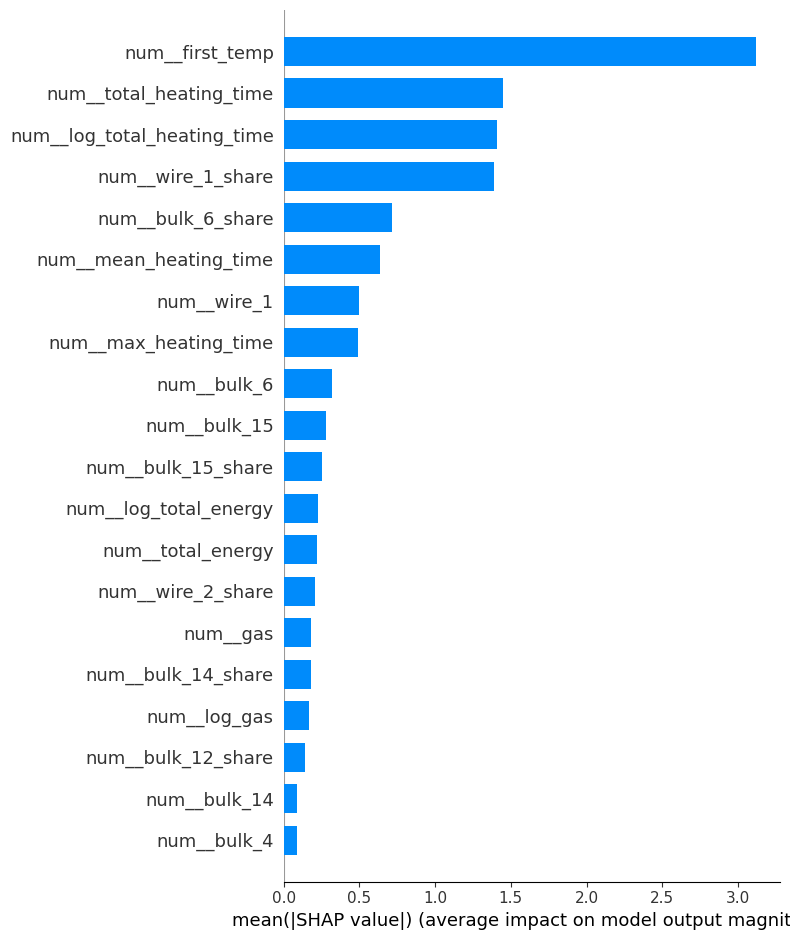

In [130]:
best_name = results_df.iloc[0]['Model']
pipeline = best_estimators[best_name]

preprocessor = pipeline.named_steps['preprocessor']
selector = pipeline.named_steps['select']
model = pipeline.named_steps['model']

# preprocess
X_test_preprocessed = preprocessor.transform(X_test)
feature_names_all = preprocessor.get_feature_names_out()

mask = selector.get_support()
selected_features = np.array(feature_names_all)[mask]

X_test_selected = selector.transform(X_test_preprocessed)

# делаем DataFrame для красивых подписей
X_test_sel_df = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test.index)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sel_df)

shap.summary_plot(shap_values, X_test_sel_df, plot_type='bar')

Начальная температура партии (first_temp) — главный фактор.
Чем выше стартовая температура, тем выше итоговая. Это базовая физическая зависимость.

Параметры нагрева, прежде всего:
-общее время нагрева (total_heating_time),
- средняя и максимальная длительность нагревов,
- суммарная энергия (total_energy).

Состав добавляемых материалов (bulk/wire) влияет на итоговую температуру, но заметно слабее, чем параметры нагрева. Это означает, что материалы корректируют результат, но не являются главным драйвером температуры.

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>хорошо, что используешь этот инструмент. На начальном этапе мы можем нагенерить множество разных фич, в том числе и лишних. И вот этот инструмент, вкупе с анализом мультиколлинеарности позволяет избавляться от "балласта"). И этот баллст можно исключить и перестроить модель. Метрика не должна сильно измениться.

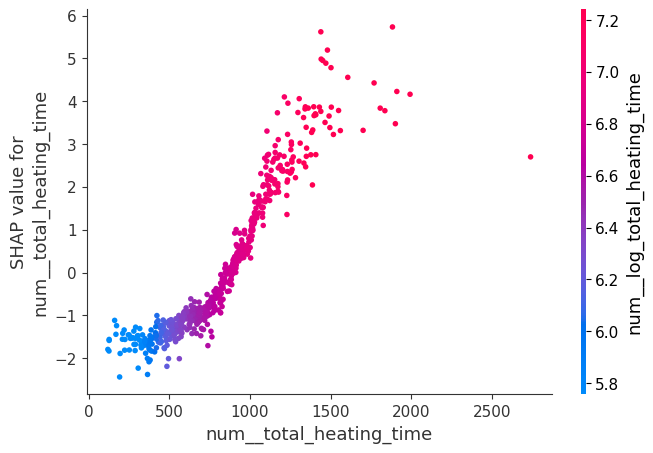

In [ ]:
# SHAP-зависимость для признака 'total_heating_time'
shap.dependence_plot('num__total_heating_time', shap_values, X_test_selected, feature_names=selected_features)

- При увеличении total_heating_time SHAP резко растёт
- Зависимость нелинейная (S-образная)
- После ~1500–1800 сек рост начинает замедляться

Это значит, что если малое время нагрева, то модель понижает прогноз температуры. И наоборот - большое время - повышает прогноз.

Интересное наблюдение, что в топ признаков оказались и `total_heating_time` и `log_total_heating_time`. Это означает, что логарифм реально добавил полезную информацию.

### Упрощение модели по отбору признаков

На основе анализа важности признаков (SHAP) я хочу провести дополнительный эксперимент по упрощению модели. Из исходного набора признаков оставлю только наиболее значимые факторы(ТОП-15), чтобы проверить, можно ли упростить модель без существенной потери качества.

Для этого повторно обучу лучшая модель — Random Forest — с теми же гиперпараметрами, но на сокращённом наборе признаков.

In [154]:
top_features = [
    'first_temp',
    'total_heating_time',
    'log_total_heating_time',
    'wire_1_share',
    'bulk_6_share',
    'mean_heating_time',
    'wire_1',
    'max_heating_time',
    'bulk_6',
    'bulk_15',
    'bulk_15_share',
    'log_total_energy',
    'total_energy',
    'wire_2_share',
    'gas'
]

X_reduced = data_agg[top_features]
y = data_agg['last_temp']

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.25, random_state=RANDOM_STATE
)

In [153]:
# модель случайного леса с лучшими параметрами
rf_model = RandomForestRegressor(
    max_depth=17,
    min_samples_leaf=5,
    min_samples_split=8,
    n_estimators=160,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")

MAE: 6.207
R2: 0.396


В результате эксперимента значение метрики MAE увеличилось с 6.13 до 6.20, а коэффициент детерминации R² снизился с 0.43 до 0.395. Таким образом, удаление части признаков действительно немного упрощает модель, однако приводит к снижению её точности.

## Вывод

В качестве baseline моделей были обучены Dummy-регрессоры.
MAE составил:
- Dummy (mean) — 8.12
- Dummy (median) — 8.08

Это показывает, что простое предсказание среднего значения даёт ошибку около 8 градусов.

___

Лучшей моделью по результатам кросс-валидации стала RandomForest:
- CV MAE = 6.33
- MAE на тесте = 6.13
- R² на тесте = 0.42

Таким образом, модель существенно превосходит baseline (снижение ошибки примерно на 2 градуса) и удовлетворяет требованию задачи — MAE < 6.8.

___

Нейросетевая модель после улучшений показала:
- MAE = 6.89
- R² = 0.16

Несмотря на улучшения, нейросеть не достигла требуемого качества (MAE ниже 6.8) и значительно уступает градиентному бустингу как по ошибке, так и по объясняющей способности.

___

Таким образом, для данной производственной задачи лучше всего себя показал градиентный бустинг (CatBoost).
Модель обеспечивает требуемую точность, демонстрирует стабильность между CV и тестом, соответствует физической логике процесса (что подтверждается SHAP-анализом).

-----

Основной рычаг управления температурой — режим нагрева, а не изменение состава добавок.                                  
Оптимизация должна в первую очередь быть направлена на:
- сокращение избыточного времени нагрева,
- настройку количества циклов нагрева.

Поскольку модель выявила эффект насыщения, увеличение времени нагрева после определённой точки даёт всё меньший прирост температуры, но продолжает увеличивать энергозатраты.
Это зона потенциальной экономии.                                

Стоит отметить, что данная модель отвечает на вопрос "что будет?", но не отвечает напрямую на "что сделать, чтобы стало лучше?".                   
Чтобы реально снижать энергопотребление, нужно перейти от прогноза к управлению. Важность начальной температуры — это полезный инсайт, но из этого не следует, что мы можем ею управлять.               
Получается, начальная температура — ключевой фактор вариативности результата. Нужно выяснить, является ли он управляемым (или хотя бы косвенно управляемым) через регламенты предыдущих этапов/ожидания/температурные потери.

То есть модель помогает найти, где копать. На основе этих выводов можно сделать рекомендации по внедрению для производства.


<b>Рекомендации по внедрению модели</b>

На основе результатов моделирования и анализа важности признаков можно предложить следующие направления практического применения модели на производстве.

1. Использование модели для прогнозирования температуры сплава.
Разработанную модель можно использовать для предварительного прогнозирования конечной температуры плавки на основе параметров технологического процесса. Это позволит заранее оценивать, достигнет ли температура требуемых значений.

2. Поддержка принятия технологических решений.
Прогноз температуры может использоваться технологами для корректировки режима нагрева, количества добавляемых материалов и времени обработки, чтобы избежать перегрева или недогрева сплава.

3. Снижение энергопотребления.
Использование модели позволяет выявлять режимы обработки, при которых достигается требуемая температура при меньших затратах электроэнергии, что может способствовать повышению энергоэффективности производства.

4. Мониторинг отклонений технологического процесса.
Модель может использоваться для выявления партий, где прогнозируемая температура существенно отличается от ожидаемой. Это позволит оперативно обнаруживать нестандартные режимы работы оборудования или изменения в составе сырья.

5. Анализ факторов, влияющих на температуру.
Анализ важности признаков (SHAP) показал, какие параметры технологического процесса оказывают наибольшее влияние на конечную температуру. Эти результаты могут быть использованы технологами для дальнейшего анализа и оптимизации процесса.

6. Использование модели в системе поддержки принятия решений.
Модель может быть встроена в информационную систему предприятия для автоматического расчёта прогнозной температуры при вводе параметров технологического процесса - "температура вне допуска / в допуске".

7. Дальнейшее развитие модели.
Для повышения точности и практической ценности модели рекомендуется расширить набор данных, включая дополнительные параметры производства (например, характеристики сырья, состояние оборудования или параметры предыдущих этапов обработки).

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-success" style="border-color: green; border-radius: 5px">
<b> КОММЕНТАРИЙ МЕНТОРА 2</b><br>
Доброго дня, Ксения!<br>
Увидел, корректироки/комментарии. Вопросов нет, всё по делу. Если говорить о цели проекта, как о доказательстве того, что студент владеет аналитическим материалом и может бизнес-задачу переводить в метод решения и обратно трансформириовать в бизнес-рекомендации, то уверенно заявляю, глядя на этот проект - цель достигнута!). Что ж, в принципе, всё на этом. Как говорится "Проекту конец, а кто справился - МОЛОДЕЦ":)<br>
Далее, на правах ментора, скажу, что стараюсь говорить всем на финале.<br>
Пройден большой путь. Со своими коcогорами и равнинами, медианами и дисперсиями)<br>
Умение аналитически мыслить, писать красивый код, эффективно автоматизировать расчёты, видеть задачи бизнеса через призму моделирования - вот то основное, что  останется у тебя важного после нашей школы. А дальше - только взращивать посеянные зёрна и укреплять свои скилы.<br><br>
Если говорить о развитии дополнительных компетенций, рекомендовал бы ещё глянуть такие области знаний:<br>
1) Организация проектов по проведению моделирования (например Методология CRISP-DM (Cross-Industry Standard Process)<br>
2) Умения системно подходить к решению аналитической задачи. (например методология ТРИЗ, системный анализ)<br>
3) Если в промышленности будут проекты, то рекоммендовал бы освоить  "Статистичекий контроль качества (SPC)"<br>
4) Ещё важный навык: перевод результататов моделирования на язык бизнеса. Т.е. понимание, как целевые показатели моделей влияют на финансовую выгоду заказчика.<br>

    
Спасибо за этот труд, за активную позицию при работе!<br>
Искренне желаю покорить ещё не один аналитический Эверест)<br>

<div class="alert alert-success" style="border-color: green; border-radius: 5px">
    <p><u><b>✅ КОММЕНТАРИЙ МЕНТОРА</b></u></p>
ОК, Ксения, отличная работа! Тут и аналитика, и графика, и рассуждения. При это в меру и достаточно. С уверенностью можно сказать, что пройден весь алгоритм моделирования от анализа исходной инфо до анализа важности факторов.<br> 
<br>
<font color='red'>      
Есть лишь несколько комментов. Постарался их выделить цветом и аргументировать, посмотри, пожалуйста. На конечный ответ вряд ли повлияют. Но всё же)<br>
    
<font color='green'> 
<br><br> 
Всегда стараюсь на этом проекте сказать всем вот ещё что: цель заказчика - экономия энергоресурсов.<br>
И в этом проекте искали как раз способ точно предсказывать температуру. И круто использовали для этого весь арсенал<br>
А если рассуждать с позиции такой: а что нужно сделать, чтобы снизить энергопотребление?<br>
Судя по модели, самым важным фактором является первая температура. Это значит, что управляя ею, мы сможем управлять энергозатратами. Вывод понятен. Теперь надо разработать мероприятия для этого решения. И тут вопрос возникает скм собой: а это так точно? мы можем управлять первой температурой? В общем, наша модель - только начало работы над энергоэффективностью.<br>
    
Так же есть ещё одна идея, которую хотел предложить тебе на обсуждение.<br>
Возможно, покажется интересным<br><br> 

Дело касается принципиально иного подхода к поиску решения для снижения энергопотребления на производстве<br>
Смотри, Создание данной модели (таково было задание) двигалось по пути "угадывания" температуры<br>
Но мы же знаем жизнь)) лёгкие колебания температур (как и нашего настроения, нашего веса.....)<br>
есть всегда. Более того - будут вегда! И нам что, стараться угадывать их?<br>
Не угонимся, "пупок" развяжется))))) <br>
Предложу для подобных проектов подумать вот в какую сторону<br>
    
Итак, разброс в измерениях - есть, был и будет!! (т.к. этому благоприятствует разнообразие факторов самого проиозводства)<br>
    Тогда задачу можно поставить так: <u>надо уменьшить разброс в измерениях</u>. В данном случае в температуре.<br>
Один из подходов такой: Наверняка есть границы, в пределах которых колебания температур - дело нормальное.<br>
А что, если фикировать случаи, когда температура выходит за эти границы?<br>
Скажем, как "1". И тогда для таких моментов времени собирать инфо по производству: <br>
а что был за материал (химия материала), что был за газ (химический состав газа), какая бригада работала, <br>
что там было с электродами, ограничения только в фантазиях ну и в знаниях самого производства..... <br>
И вот тут можем реально находить причины (через корреляции, проверки гипотез, разные модельки...), фиксировать эти причины. <br>
Ну и разрабатывать энергосберегательные мероприятия.<br><br>
 
Это было отступление)<br>    
Тогда впереди только то, что написал выше.<br>
БУДУ ЖДАТЬ! <br>